### 06 – Transfer Learning with MobileNetV3

This notebook develops a transfer learning model for traffic sign recognition using **MobileNetV3-Large** pretrained on ImageNet.

MobileNetV3 is designed as a computationally efficient convolutional neural network. It combines depthwise separable convolutions, inverted residual blocks, squeeze-and-excitation modules and hardware-aware architecture search.

The experiment uses two training stages:

1. **Feature extraction** – the pretrained convolutional backbone is frozen and only the new classification head is trained.
2. **Fine-tuning** – the final MobileNetV3 feature blocks are unfrozen and trained using a smaller learning rate.

The final model is evaluated using:

- test accuracy;
- macro and weighted precision, recall and F1-score;
- classification report;
- raw and normalised confusion matrices;
- per-class performance;
- best- and worst-performing classes;
- examples of incorrect predictions.

The results will later be compared with:

- HOG + SVM baseline;
- custom CNN baseline;
- ResNet18 transfer learning model.

In [1]:
import os
import sys
import time
import random
import platform
import warnings
from copy import deepcopy
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
from torchvision import transforms, models

from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

warnings.filterwarnings("ignore")

print("Python version:", sys.version)
print("Computer architecture:", platform.machine())
print("macOS version:", platform.mac_ver()[0])
print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)
print("CUDA available:", torch.cuda.is_available())
print("MPS built:", torch.backends.mps.is_built())
print("MPS available:", torch.backends.mps.is_available())

/Users/liuyuhan/opt/anaconda3/lib/python3.9/site-packages/scipy/__init__.py:155: UserWarning: A NumPy version >=1.18.5 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


Python version: 3.9.13 (main, Aug 25 2022, 18:29:29) 
[Clang 12.0.0 ]
Computer architecture: x86_64
macOS version: 10.16
PyTorch version: 2.2.2
Torchvision version: 0.17.2
CUDA available: False
MPS built: True
MPS available: False


In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

print("Random seed:", SEED)

Random seed: 42


##### 1. Experimental Configuration

The required libraries are imported and a fixed random seed is used to improve the reproducibility of the experiment.

The experiment is executed locally on an Intel-based Mac. Since CUDA and Apple MPS acceleration are unavailable in the current environment, model training is performed using the CPU.

In [3]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

available_threads = os.cpu_count() or 1
cpu_threads = max(1, available_threads - 1)

torch.set_num_threads(cpu_threads)

print("Device:", device)
print("Available CPU threads:", available_threads)
print("PyTorch CPU threads:", torch.get_num_threads())

Device: cpu
Available CPU threads: 8
PyTorch CPU threads: 7


In [4]:
current_path = Path.cwd().resolve()

if current_path.name == "notebooks":
    project_root = current_path.parent
elif (current_path / "notebooks").exists():
    project_root = current_path
else:
    project_root = current_path.parent

data_dir = project_root / "data"
processed_dir = data_dir / "processed"
raw_dir = data_dir / "raw"

models_dir = project_root / "models"
results_dir = project_root / "results"
figures_dir = results_dir / "figures"

models_dir.mkdir(parents=True, exist_ok=True)
results_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

train_csv_path = processed_dir / "train_split.csv"
validation_csv_path = processed_dir / "validation_split.csv"
test_csv_path = processed_dir / "test_split.csv"

print("Project root:", project_root)
print("Training CSV:", train_csv_path)
print("Validation CSV:", validation_csv_path)
print("Test CSV:", test_csv_path)
print("Models directory:", models_dir)
print("Results directory:", results_dir)
print("Figures directory:", figures_dir)

Project root: /Users/liuyuhan/Desktop/traffic_recognition
Training CSV: /Users/liuyuhan/Desktop/traffic_recognition/data/processed/train_split.csv
Validation CSV: /Users/liuyuhan/Desktop/traffic_recognition/data/processed/validation_split.csv
Test CSV: /Users/liuyuhan/Desktop/traffic_recognition/data/processed/test_split.csv
Models directory: /Users/liuyuhan/Desktop/traffic_recognition/models
Results directory: /Users/liuyuhan/Desktop/traffic_recognition/results
Figures directory: /Users/liuyuhan/Desktop/traffic_recognition/results/figures


In [5]:
required_files = [train_csv_path, validation_csv_path, test_csv_path]

for file_path in required_files:
    if not file_path.exists():
        raise FileNotFoundError(f"Required file not found: {file_path}")

print("All dataset split files were found successfully.")

All dataset split files were found successfully.


##### 2. Dataset Preparation

The previously generated train, validation and test splits are loaded from the processed data directory.

The training set is used to estimate model parameters, the validation set is used for model selection and early stopping, and the test set is reserved for the final evaluation.

In [6]:
train_df = pd.read_csv(train_csv_path)
validation_df = pd.read_csv(validation_csv_path)
test_df = pd.read_csv(test_csv_path)

print("Training set shape:", train_df.shape)
print("Validation set shape:", validation_df.shape)
print("Test set shape:", test_df.shape)

display(train_df.head())

Training set shape: (31367, 8)
Validation set shape: (7842, 8)
Test set shape: (12630, 8)


,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path
0,56,56,5,5,51,51,12,Train/12/00012_00031_00018.png
1,27,28,6,5,22,23,5,Train/5/00005_00031_00001.png
2,92,94,8,9,84,86,12,Train/12/00012_00069_00028.png
3,60,53,6,5,54,48,13,Train/13/00013_00052_00022.png
4,64,58,6,5,59,53,18,Train/18/00018_00017_00024.png


In [7]:
print("Training columns:", list(train_df.columns))
print("Validation columns:", list(validation_df.columns))
print("Test columns:", list(test_df.columns))

Training columns: ['Width', 'Height', 'Roi.X1', 'Roi.Y1', 'Roi.X2', 'Roi.Y2', 'ClassId', 'Path']
Validation columns: ['Width', 'Height', 'Roi.X1', 'Roi.Y1', 'Roi.X2', 'Roi.Y2', 'ClassId', 'Path']
Test columns: ['Width', 'Height', 'Roi.X1', 'Roi.Y1', 'Roi.X2', 'Roi.Y2', 'ClassId', 'Path']


##### 3. Identification of Image and Label Columns

The image path and target label columns are detected from the CSV files. Automatic detection makes the data-loading procedure less dependent on a single column naming convention. Find a column using a list of possible names, column-name matching is case-insensitive.

In [8]:
def find_column(dataframe, candidate_names):

    lower_to_original = {
        str(column).lower(): column
        for column in dataframe.columns
    }

    for candidate in candidate_names:
        if candidate.lower() in lower_to_original:
            return lower_to_original[candidate.lower()]

    return None


path_candidates = [
    "Path",
    "path",
    "filepath",
    "file_path",
    "image_path",
    "ImagePath",
    "filename",
    "file"
]

label_candidates = [
    "ClassId",
    "class_id",
    "classid",
    "label",
    "Label",
    "target",
    "class",
    "category"
]

path_column = find_column(train_df, path_candidates)
label_column = find_column(train_df, label_candidates)

if path_column is None:
    raise ValueError(
        "The image path column could not be detected. "
        f"Available columns: {list(train_df.columns)}"
    )

if label_column is None:
    raise ValueError(
        "The label column could not be detected. "
        f"Available columns: {list(train_df.columns)}"
    )

print("Detected image path column:", path_column)
print("Detected label column:", label_column)

Detected image path column: Path
Detected label column: ClassId


##### 4. Label Encoding

A consistent mapping is created between the original class labels and consecutive integer indices.

This is necessary because the neural network output layer produces one output value for each class index from `0` to `number of classes - 1`.

In [9]:
# Obtain all class labels from the training set
original_labels = sorted(train_df[label_column].unique().tolist())

label_to_index = {
    original_label: index
    for index, original_label in enumerate(original_labels)
}

index_to_label = {
    index: original_label
    for original_label, index in label_to_index.items()
}

num_classes = len(original_labels)

print("Number of classes:", num_classes)
print("First ten label mappings:")

for original_label in original_labels[:10]:
    print(f"{original_label} -> {label_to_index[original_label]}")

Number of classes: 43
First ten label mappings:
0 -> 0
1 -> 1
2 -> 2
3 -> 3
4 -> 4
5 -> 5
6 -> 6
7 -> 7
8 -> 8
9 -> 9


In [10]:
# Verify that validation and test labels also occur in the training set
validation_labels = set(validation_df[label_column].unique())
test_labels = set(test_df[label_column].unique())
training_labels = set(original_labels)

unknown_validation_labels = validation_labels - training_labels
unknown_test_labels = test_labels - training_labels

if unknown_validation_labels:
    raise ValueError(
        f"Validation set contains unknown labels: {unknown_validation_labels}"
    )

if unknown_test_labels:
    raise ValueError(
        f"Test set contains unknown labels: {unknown_test_labels}"
    )

print("All validation and test labels are represented in the training set.")

All validation and test labels are represented in the training set.


Where class metadata are available, they are used to provide readable class names in evaluation tables and visualisations. Otherwise, the original numerical class identifiers are retained.

In [11]:
meta_candidates = [raw_dir / "Meta.csv", raw_dir / "archive" / "Meta.csv"]

meta_path = next((path for path in meta_candidates if path.exists()), None)

class_display_names = {index: f"Class {index_to_label[index]}" for index in range(num_classes)}

if meta_path is not None:
    meta_df = pd.read_csv(meta_path)

    print("Metadata file:", meta_path)
    print("Metadata columns:", list(meta_df.columns))

    meta_label_column = find_column(
        meta_df,
        ["ClassId", "class_id", "classid", "label", "target"]
    )

    meta_name_column = find_column(
        meta_df,
        [
            "SignName",
            "sign_name",
            "ClassName",
            "class_name",
            "Name",
            "name",
            "Description",
            "description"
        ]
    )

    if meta_label_column is not None and meta_name_column is not None:
        metadata_name_mapping = dict(
            zip(
                meta_df[meta_label_column],
                meta_df[meta_name_column]
            )
        )

        for encoded_index, original_label in index_to_label.items():
            if original_label in metadata_name_mapping:
                class_display_names[encoded_index] = str(
                    metadata_name_mapping[original_label]
                )

        print("Readable class names were loaded from the metadata file.")
    else:
        print(
            "No readable class-name column was found. "
            "Numerical class identifiers will be used."
        )
else:
    print("Meta.csv was not found. Numerical class identifiers will be used.")

Metadata file: /Users/liuyuhan/Desktop/traffic_recognition/data/raw/archive/Meta.csv
Metadata columns: ['Path', 'ClassId', 'ShapeId', 'ColorId', 'SignId']
No readable class-name column was found. Numerical class identifiers will be used.


##### 5. Image Preprocessing, Transforms and Data Augmentation

All images are resized to `224 × 224`, which is the standard input resolution used by the pretrained MobileNetV3 model.

The training transformation includes moderate data augmentation:

- random rotation;
- random affine translation and scaling;
- colour jitter.

These transformations introduce realistic variation while preserving the identity of the traffic sign.

Horizontal flipping is not used because flipping a traffic sign may change its semantic meaning.

Validation and test images are resized and normalised without random augmentation. ImageNet mean and standard deviation values are used because the pretrained model was originally trained using this normalisation.

In [12]:
IMAGE_SIZE = 224

imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

    transforms.RandomRotation(
        degrees=10,
        fill=0
    ),

    transforms.RandomAffine(
        degrees=0,
        translate=(0.08, 0.08),
        scale=(0.90, 1.10),
        fill=0
    ),

    transforms.ColorJitter(
        brightness=0.20,
        contrast=0.20,
        saturation=0.15
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=imagenet_mean,
        std=imagenet_std
    )
])

evaluation_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=imagenet_mean,
        std=imagenet_std
    )
])

print("Training transformations:")
print(train_transform)

print("\nValidation and test transformations:")
print(evaluation_transform)

Training transformations:
Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    RandomRotation(degrees=[-10.0, 10.0], interpolation=nearest, expand=False, fill=0)
    RandomAffine(degrees=[0.0, 0.0], translate=(0.08, 0.08), scale=(0.9, 1.1))
    ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=(0.85, 1.15), hue=None)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

Validation and test transformations:
Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


##### 6. Custom Traffic Sign Dataset

A custom PyTorch dataset reads image locations and class labels from the CSV split files.

The image path resolver checks several possible locations because paths stored in the CSV files may be relative to either the project root or the raw dataset directory.

Several candidate locations are checked to support paths that are relative to the project root, data directory or raw dataset directory

In [13]:
# Resolve an image path stored in a CSV file
def resolve_image_path(stored_path):
    stored_path = Path(str(stored_path))
    candidates = []

    # Use the path directly when it is already absolute
    if stored_path.is_absolute():
        candidates.append(stored_path)

    # Common relative-path possibilities
    candidates.extend([
        project_root / stored_path,
        data_dir / stored_path,
        raw_dir / stored_path,
        raw_dir / "archive" / stored_path,
        raw_dir / "archive" / "Train" / stored_path,
        raw_dir / "archive" / "Test" / stored_path
    ])

    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()

    raise FileNotFoundError(
        f"Image could not be located: {stored_path}\n"
        f"Checked locations:\n" +
        "\n".join(str(candidate) for candidate in candidates)
    )

In [14]:
# Traffic sign image dataset based on a CSV split file
class TrafficSignDataset(Dataset):

    def __init__(
        self,
        dataframe,
        image_path_column,
        target_column,
        label_mapping,
        transform=None
    ):
        self.dataframe = dataframe.reset_index(drop=True).copy()
        self.image_path_column = image_path_column
        self.target_column = target_column
        self.label_mapping = label_mapping
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]

        image_path = resolve_image_path(
            row[self.image_path_column]
        )

        with Image.open(image_path) as image:
            image = image.convert("RGB")

        original_label = row[self.target_column]
        encoded_label = self.label_mapping[original_label]

        if self.transform is not None:
            image = self.transform(image)

        return image, encoded_label, str(image_path)

##### 7. Data Loaders

Data loaders organise images into mini-batches.

A batch size of 32 is used as a compromise between training speed and memory usage. Since training is performed locally on a CPU, `num_workers=0` is used to avoid multiprocessing issues that can occur in Jupyter notebooks on macOS.

A single mini-batch is inspected to confirm that:

- images have three colour channels;
- images have the expected spatial dimensions;
- labels are encoded correctly;
- the data loader returns valid image paths.

In [15]:
train_dataset = TrafficSignDataset(
    dataframe=train_df,
    image_path_column=path_column,
    target_column=label_column,
    label_mapping=label_to_index,
    transform=train_transform
)

validation_dataset = TrafficSignDataset(
    dataframe=validation_df,
    image_path_column=path_column,
    target_column=label_column,
    label_mapping=label_to_index,
    transform=evaluation_transform
)

test_dataset = TrafficSignDataset(
    dataframe=test_df,
    image_path_column=path_column,
    target_column=label_column,
    label_mapping=label_to_index,
    transform=evaluation_transform
)

print("Training images:", len(train_dataset))
print("Validation images:", len(validation_dataset))
print("Test images:", len(test_dataset))

Training images: 31367
Validation images: 7842
Test images: 12630


In [16]:
BATCH_SIZE = 32
NUM_WORKERS = 0

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=False,
    drop_last=False
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=False,
    drop_last=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=False,
    drop_last=False
)

print("Training batches:", len(train_loader))
print("Validation batches:", len(validation_loader))
print("Test batches:", len(test_loader))

Training batches: 981
Validation batches: 246
Test batches: 395


In [17]:
# Data loader verification
sample_images, sample_labels, sample_paths = next(iter(train_loader))

print("Image batch shape:", sample_images.shape)
print("Label batch shape:", sample_labels.shape)
print("Image data type:", sample_images.dtype)
print("First five encoded labels:", sample_labels[:5].tolist())
print("First image path:", sample_paths[0])

Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])
Image data type: torch.float32
First five encoded labels: [17, 38, 7, 13, 25]
First image path: /Users/liuyuhan/Desktop/traffic_recognition/data/raw/archive/Train/17/00017_00029_00004.png


##### 8. Visual Inspection of Training Data

Several transformed training images are displayed to check that the augmentation pipeline produces plausible examples and does not destroy important traffic sign information.

In [18]:
# Reverse ImageNet normalisation for visualisation
def denormalise_image(image_tensor):
    
    image = image_tensor.detach().cpu().clone()

    mean = torch.tensor(imagenet_mean).view(3, 1, 1)
    std = torch.tensor(imagenet_std).view(3, 1, 1)

    image = image * std + mean
    image = torch.clamp(image, 0, 1)

    return image.permute(1, 2, 0).numpy()

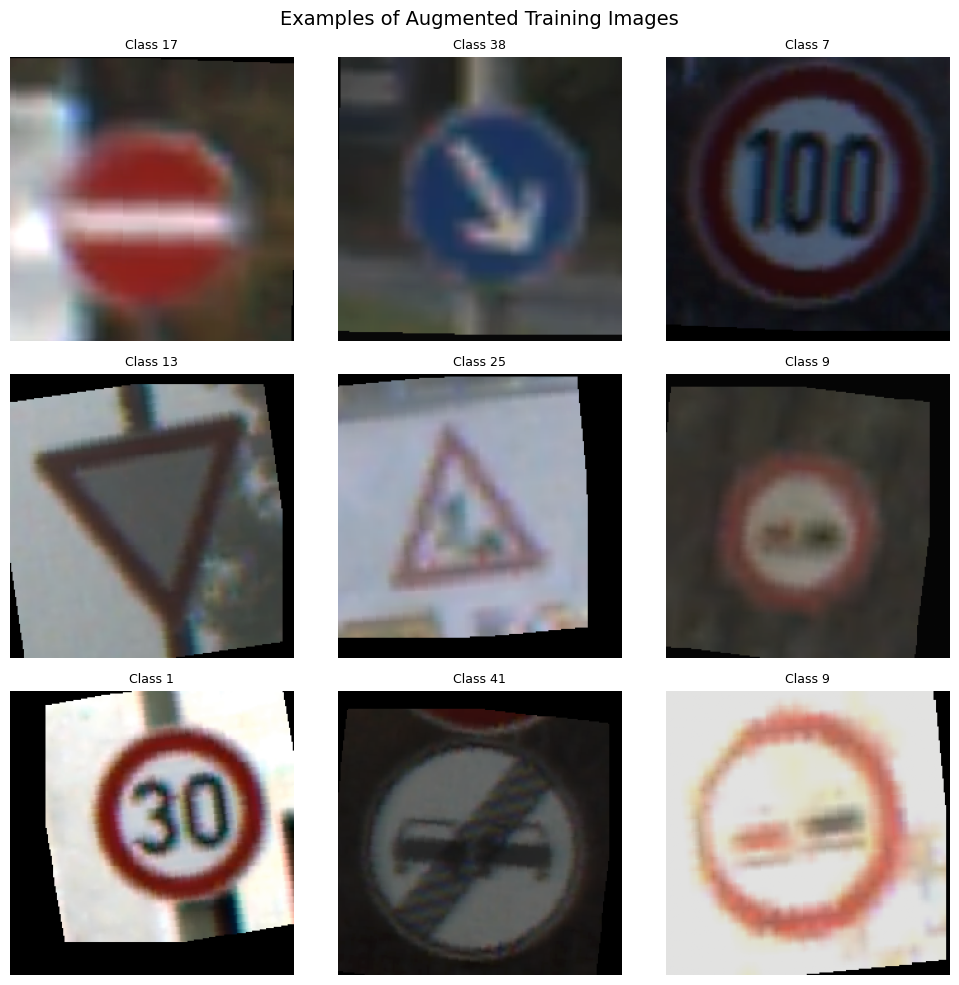

Figure saved to: /Users/liuyuhan/Desktop/traffic_recognition/results/figures/mobilenetv3_augmented_training_samples.png


In [19]:
num_samples_to_show = min(9, len(sample_images))

fig, axes = plt.subplots(3, 3, figsize=(10, 10))
axes = axes.flatten()

for index in range(len(axes)):
    axes[index].axis("off")

    if index < num_samples_to_show:
        image = denormalise_image(sample_images[index])
        encoded_label = sample_labels[index].item()

        axes[index].imshow(image)
        axes[index].set_title(
            class_display_names[encoded_label],
            fontsize=9
        )

plt.suptitle("Examples of Augmented Training Images", fontsize=14)
plt.tight_layout()

sample_figure_path = (figures_dir / "mobilenetv3_augmented_training_samples.png")

plt.savefig(sample_figure_path, dpi=300, bbox_inches="tight")

plt.show()

print("Figure saved to:", sample_figure_path)

##### 9. MobileNetV3 Transfer Learning Model

MobileNetV3-Large pretrained on ImageNet is used as the feature extractor.

The original final classification layer predicts 1,000 ImageNet categories. It is replaced with a new linear layer whose number of outputs matches the number of traffic sign classes.

Initially, all convolutional feature-extraction parameters are frozen. Only the newly created classification layer is trainable.

In [20]:
# Load pretrained ImageNet weights
weights = models.MobileNet_V3_Large_Weights.DEFAULT

model = models.mobilenet_v3_large(weights=weights)

print(model.classifier)

Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-5c1a4163.pth" to /Users/liuyuhan/.cache/torch/hub/checkpoints/mobilenet_v3_large-5c1a4163.pth
100%|██████████| 21.1M/21.1M [00:00<00:00, 32.8MB/s]

Sequential(
  (0): Linear(in_features=960, out_features=1280, bias=True)
  (1): Hardswish()
  (2): Dropout(p=0.2, inplace=True)
  (3): Linear(in_features=1280, out_features=1000, bias=True)
)


In [21]:
# Freeze the pretrained feature extractor
for parameter in model.features.parameters():
    parameter.requires_grad = False

# Replace the final ImageNet classification layer
input_features = model.classifier[3].in_features

model.classifier[3] = nn.Linear(input_features, num_classes)

model = model.to(device)

print("Final classifier:")
print(model.classifier)

print("\nNumber of output classes:", num_classes)

Final classifier:
Sequential(
  (0): Linear(in_features=960, out_features=1280, bias=True)
  (1): Hardswish()
  (2): Dropout(p=0.2, inplace=True)
  (3): Linear(in_features=1280, out_features=43, bias=True)
)

Number of output classes: 43


##### 10. Parameter Configuration

The final layer is randomly initialised because it is specific to the traffic sign dataset. In contrast, the convolutional backbone retains the pretrained ImageNet feature representations.

Freezing the backbone reduces training time and prevents the pretrained representations from being changed substantially during the initial training stage.

In [22]:
def count_parameters(neural_network):
    total_parameters = sum(
        parameter.numel()
        for parameter in neural_network.parameters()
    )

    trainable_parameters = sum(
        parameter.numel()
        for parameter in neural_network.parameters()
        if parameter.requires_grad
    )

    frozen_parameters = total_parameters - trainable_parameters

    return (total_parameters, trainable_parameters, frozen_parameters)


total_parameters, trainable_parameters, frozen_parameters = (count_parameters(model))

print(f"Total parameters: {total_parameters:,}")
print(f"Trainable parameters: {trainable_parameters:,}")
print(f"Frozen parameters: {frozen_parameters:,}")
print("Trainable percentage:", f"{100 * trainable_parameters / total_parameters:.2f}%")

Total parameters: 4,257,115
Trainable parameters: 1,285,163
Frozen parameters: 2,971,952
Trainable percentage: 30.19%


##### 11. Loss Function and Optimisation

Cross-entropy loss is used because the task is a single-label multiclass classification problem.

AdamW is used to optimise the newly created classification layer. A learning-rate scheduler reduces the learning rate when validation loss stops improving.

Early stopping is also used to restore the model state that achieved the lowest validation loss.

In [23]:
criterion = nn.CrossEntropyLoss()

FEATURE_EXTRACTION_LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

feature_extraction_optimizer = optim.AdamW(
    filter(
        lambda parameter: parameter.requires_grad,
        model.parameters()
    ),
    lr=FEATURE_EXTRACTION_LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

feature_extraction_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    feature_extraction_optimizer,
    mode="min",
    factor=0.5,
    patience=1
)

print("Loss function:", criterion)
print("Feature extraction optimiser:", feature_extraction_optimizer)

Loss function: CrossEntropyLoss()
Feature extraction optimiser: AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0.0001
)


##### 12. Training Functions

Separate functions are defined for one training epoch and one validation epoch.

The training function performs backpropagation and parameter updates. The validation function evaluates the model without gradient calculation or parameter updates.

In [24]:
def train_one_epoch(neural_network, data_loader, loss_function, optimizer, computation_device):
    neural_network.train()

    running_loss = 0.0
    correct_predictions = 0
    total_examples = 0

    for images, labels, _ in data_loader:
        images = images.to(computation_device)
        labels = labels.to(computation_device)

        optimizer.zero_grad(set_to_none=True)

        outputs = neural_network(images)
        loss = loss_function(outputs, labels)

        loss.backward()
        optimizer.step()

        batch_size = images.size(0)

        running_loss += loss.item() * batch_size

        predictions = outputs.argmax(dim=1)

        correct_predictions += (
            predictions == labels
        ).sum().item()

        total_examples += batch_size

    epoch_loss = running_loss / total_examples
    epoch_accuracy = correct_predictions / total_examples

    return epoch_loss, epoch_accuracy

In [25]:
def evaluate_one_epoch(neural_network, data_loader, loss_function, computation_device):
    neural_network.eval()

    running_loss = 0.0
    correct_predictions = 0
    total_examples = 0

    with torch.no_grad():
        for images, labels, _ in data_loader:
            images = images.to(computation_device)
            labels = labels.to(computation_device)

            outputs = neural_network(images)
            loss = loss_function(outputs, labels)

            batch_size = images.size(0)

            running_loss += loss.item() * batch_size

            predictions = outputs.argmax(dim=1)

            correct_predictions += (
                predictions == labels
            ).sum().item()

            total_examples += batch_size

    epoch_loss = running_loss / total_examples
    epoch_accuracy = correct_predictions / total_examples

    return epoch_loss, epoch_accuracy

In [26]:
def train_model(
    neural_network,
    train_data_loader,
    validation_data_loader,
    loss_function,
    optimizer,
    scheduler,
    computation_device,
    number_of_epochs,
    patience,
    stage_name
):
    history = {
        "stage": [],
        "epoch": [],
        "train_loss": [],
        "train_accuracy": [],
        "validation_loss": [],
        "validation_accuracy": [],
        "learning_rate": [],
        "epoch_time_seconds": []
    }

    best_model_state = deepcopy(
        neural_network.state_dict()
    )

    best_validation_loss = float("inf")
    epochs_without_improvement = 0

    stage_start_time = time.time()

    for epoch in range(1, number_of_epochs + 1):
        epoch_start_time = time.time()

        current_learning_rate = (
            optimizer.param_groups[0]["lr"]
        )

        train_loss, train_accuracy = train_one_epoch(
            neural_network=neural_network,
            data_loader=train_data_loader,
            loss_function=loss_function,
            optimizer=optimizer,
            computation_device=computation_device
        )

        validation_loss, validation_accuracy = evaluate_one_epoch(
            neural_network=neural_network,
            data_loader=validation_data_loader,
            loss_function=loss_function,
            computation_device=computation_device
        )

        epoch_time = time.time() - epoch_start_time

        history["stage"].append(stage_name)
        history["epoch"].append(epoch)
        history["train_loss"].append(train_loss)
        history["train_accuracy"].append(train_accuracy)
        history["validation_loss"].append(validation_loss)
        history["validation_accuracy"].append(
            validation_accuracy
        )
        history["learning_rate"].append(
            current_learning_rate
        )
        history["epoch_time_seconds"].append(epoch_time)

        print(
            f"{stage_name} | "
            f"Epoch {epoch:02d}/{number_of_epochs:02d} | "
            f"Train loss: {train_loss:.4f} | "
            f"Train accuracy: {train_accuracy:.4f} | "
            f"Validation loss: {validation_loss:.4f} | "
            f"Validation accuracy: {validation_accuracy:.4f} | "
            f"LR: {current_learning_rate:.2e} | "
            f"Time: {epoch_time:.1f}s"
        )

        if scheduler is not None:
            scheduler.step(validation_loss)

        if validation_loss < best_validation_loss:
            best_validation_loss = validation_loss

            best_model_state = deepcopy(
                neural_network.state_dict()
            )

            epochs_without_improvement = 0

            print(
                "  Validation loss improved. "
                "Best model state updated."
            )
        else:
            epochs_without_improvement += 1

            print(
                "  Validation loss did not improve. "
                f"Early-stopping counter: "
                f"{epochs_without_improvement}/{patience}"
            )

        if epochs_without_improvement >= patience:
            print(
                f"Early stopping activated during "
                f"{stage_name}."
            )
            break

    neural_network.load_state_dict(best_model_state)

    total_stage_time = time.time() - stage_start_time

    print(
        f"\n{stage_name} completed in "
        f"{total_stage_time / 60:.2f} minutes."
    )

    print(
        f"Best validation loss: "
        f"{best_validation_loss:.4f}"
    )

    return neural_network, pd.DataFrame(history)

##### 13. Stage 1 - Feature Extraction

During the first stage, the MobileNetV3 convolutional feature extractor remains frozen, while the classification head remains trainable. The final ImageNet output layer has been replaced with a new layer containing 43 outputs for the traffic sign classes.

This allows the classifier to adapt the general ImageNet features to the traffic sign categories with relatively low computational cost.

In [27]:
FEATURE_EXTRACTION_EPOCHS = 5
EARLY_STOPPING_PATIENCE = 3

model, feature_extraction_history = train_model(
    neural_network=model,
    train_data_loader=train_loader,
    validation_data_loader=validation_loader,
    loss_function=criterion,
    optimizer=feature_extraction_optimizer,
    scheduler=feature_extraction_scheduler,
    computation_device=device,
    number_of_epochs=FEATURE_EXTRACTION_EPOCHS,
    patience=EARLY_STOPPING_PATIENCE,
    stage_name="Feature extraction"
)

Feature extraction | Epoch 01/05 | Train loss: 1.0886 | Train accuracy: 0.6573 | Validation loss: 0.7804 | Validation accuracy: 0.7465 | LR: 1.00e-03 | Time: 1753.3s
  Validation loss improved. Best model state updated.
Feature extraction | Epoch 02/05 | Train loss: 0.6528 | Train accuracy: 0.7795 | Validation loss: 0.6276 | Validation accuracy: 0.7914 | LR: 1.00e-03 | Time: 2445.1s
  Validation loss improved. Best model state updated.
Feature extraction | Epoch 03/05 | Train loss: 0.5516 | Train accuracy: 0.8145 | Validation loss: 0.5202 | Validation accuracy: 0.8270 | LR: 1.00e-03 | Time: 3099.7s
  Validation loss improved. Best model state updated.
Feature extraction | Epoch 04/05 | Train loss: 0.4867 | Train accuracy: 0.8351 | Validation loss: 0.4809 | Validation accuracy: 0.8365 | LR: 1.00e-03 | Time: 34262.1s
  Validation loss improved. Best model state updated.
Feature extraction | Epoch 05/05 | Train loss: 0.4424 | Train accuracy: 0.8498 | Validation loss: 0.4442 | Validation a

In [28]:
# Inspect stage 1 history
display(feature_extraction_history)

,stage,epoch,train_loss,train_accuracy,validation_loss,validation_accuracy,learning_rate,epoch_time_seconds
0,Feature extraction,1,1.088596,0.657347,0.780387,0.746493,0.001,1753.276575
1,Feature extraction,2,0.652763,0.779482,0.627571,0.791380,0.001,2445.147039
2,Feature extraction,3,0.551607,0.814518,0.520231,0.826957,0.001,3099.654512
3,Feature extraction,4,0.486722,0.835113,0.480915,0.836521,0.001,34262.133761
4,Feature extraction,5,0.442432,0.849778,0.444207,0.855394,0.001,2435.951898


In [29]:
stage_one_history_path = (results_dir / "mobilenetv3_feature_extraction_history.csv")

feature_extraction_history.to_csv(stage_one_history_path, index=False)

print("Feature extraction history saved to:", stage_one_history_path)

Feature extraction history saved to: /Users/liuyuhan/Desktop/traffic_recognition/results/mobilenetv3_feature_extraction_history.csv


##### 14. Stage 2 - Fine-Tuning

After training the classification head, the final three feature blocks of MobileNetV3 are unfrozen.

Earlier feature blocks remain frozen because they generally represent transferable low-level visual features such as edges, colours and textures. The later blocks contain more task-specific representations and are therefore adapted to the traffic sign dataset.

A smaller learning rate is used during fine-tuning to reduce the risk of destroying useful pretrained representations.

In [30]:
# Keep the complete feature extractor frozen initially
for parameter in model.features.parameters():
    parameter.requires_grad = False

# Unfreeze only the final three MobileNetV3 feature blocks
for feature_block in model.features[-3:]:
    for parameter in feature_block.parameters():
        parameter.requires_grad = True

# Keep the classification head trainable
for parameter in model.classifier.parameters():
    parameter.requires_grad = True

total_parameters, trainable_parameters, frozen_parameters = (count_parameters(model))

print(f"Total parameters: {total_parameters:,}")
print(f"Trainable parameters: {trainable_parameters:,}")
print(f"Frozen parameters: {frozen_parameters:,}")
print("Trainable percentage:", f"{100 * trainable_parameters / total_parameters:.2f}%")

Total parameters: 4,257,115
Trainable parameters: 3,035,403
Frozen parameters: 1,221,712
Trainable percentage: 71.30%


In [31]:
# Optimiser
FINE_TUNING_LEARNING_RATE = 1e-4

fine_tuning_optimizer = optim.AdamW(
    filter(
        lambda parameter: parameter.requires_grad,
        model.parameters()
    ),
    lr=FINE_TUNING_LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

fine_tuning_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    fine_tuning_optimizer,
    mode="min",
    factor=0.5,
    patience=1
)

print("Fine-tuning optimiser:")
print(fine_tuning_optimizer)

Fine-tuning optimiser:
AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0.0001
)


In [32]:
FINE_TUNING_EPOCHS = 5

model, fine_tuning_history = train_model(
    neural_network=model,
    train_data_loader=train_loader,
    validation_data_loader=validation_loader,
    loss_function=criterion,
    optimizer=fine_tuning_optimizer,
    scheduler=fine_tuning_scheduler,
    computation_device=device,
    number_of_epochs=FINE_TUNING_EPOCHS,
    patience=EARLY_STOPPING_PATIENCE,
    stage_name="Fine-tuning"
)

Fine-tuning | Epoch 01/05 | Train loss: 0.1872 | Train accuracy: 0.9353 | Validation loss: 0.1243 | Validation accuracy: 0.9588 | LR: 1.00e-04 | Time: 6001.0s
  Validation loss improved. Best model state updated.
Fine-tuning | Epoch 02/05 | Train loss: 0.1030 | Train accuracy: 0.9654 | Validation loss: 0.0869 | Validation accuracy: 0.9707 | LR: 1.00e-04 | Time: 1506.8s
  Validation loss improved. Best model state updated.
Fine-tuning | Epoch 03/05 | Train loss: 0.0762 | Train accuracy: 0.9744 | Validation loss: 0.0702 | Validation accuracy: 0.9758 | LR: 1.00e-04 | Time: 1518.5s
  Validation loss improved. Best model state updated.
Fine-tuning | Epoch 04/05 | Train loss: 0.0597 | Train accuracy: 0.9795 | Validation loss: 0.0629 | Validation accuracy: 0.9795 | LR: 1.00e-04 | Time: 1454.9s
  Validation loss improved. Best model state updated.
Fine-tuning | Epoch 05/05 | Train loss: 0.0487 | Train accuracy: 0.9827 | Validation loss: 0.0518 | Validation accuracy: 0.9825 | LR: 1.00e-04 | Tim

In [33]:
display(fine_tuning_history)

,stage,epoch,train_loss,train_accuracy,validation_loss,validation_accuracy,learning_rate,epoch_time_seconds
0,Fine-tuning,1,0.187173,0.935282,0.124292,0.958812,0.0001,6000.972775
1,Fine-tuning,2,0.102970,0.965410,0.086916,0.970671,0.0001,1506.780749
2,Fine-tuning,3,0.076223,0.974432,0.070167,0.975771,0.0001,1518.549369
3,Fine-tuning,4,0.059734,0.979533,0.062883,0.979470,0.0001,1454.905212
4,Fine-tuning,5,0.048698,0.982657,0.051845,0.982530,0.0001,1784.257763


In [34]:
stage_two_history_path = (results_dir / "mobilenetv3_fine_tuning_history.csv")

fine_tuning_history.to_csv(stage_two_history_path, index=False)

print("Fine-tuning history saved to:", stage_two_history_path)

Fine-tuning history saved to: /Users/liuyuhan/Desktop/traffic_recognition/results/mobilenetv3_fine_tuning_history.csv


##### 15. Training History

The histories from feature extraction and fine-tuning are combined to show the complete optimisation process.

A vertical dashed line marks the transition from frozen feature extraction to partial fine-tuning.

In [35]:
feature_history_for_combination = (feature_extraction_history.copy())

fine_tuning_history_for_combination = (fine_tuning_history.copy())

feature_history_for_combination["global_epoch"] = np.arange(1, len(feature_history_for_combination) + 1)

fine_tuning_history_for_combination["global_epoch"] = np.arange(
    len(feature_history_for_combination) + 1,
    len(feature_history_for_combination)
    + len(fine_tuning_history_for_combination)
    + 1
)

combined_history = pd.concat([feature_history_for_combination, fine_tuning_history_for_combination], ignore_index=True)

combined_history_path = (results_dir / "mobilenetv3_training_history.csv")

combined_history.to_csv(combined_history_path, index=False)

display(combined_history)

print("Combined history saved to:", combined_history_path)

,stage,epoch,train_loss,train_accuracy,validation_loss,validation_accuracy,learning_rate,epoch_time_seconds,global_epoch
0,Feature extraction,1,1.088596,0.657347,0.780387,0.746493,0.0010,1753.276575,1
1,Feature extraction,2,0.652763,0.779482,0.627571,0.791380,0.0010,2445.147039,2
2,Feature extraction,3,0.551607,0.814518,0.520231,0.826957,0.0010,3099.654512,3
3,Feature extraction,4,0.486722,0.835113,0.480915,0.836521,0.0010,34262.133761,4
4,Feature extraction,5,0.442432,0.849778,0.444207,0.855394,0.0010,2435.951898,5
5,Fine-tuning,1,0.187173,0.935282,0.124292,0.958812,0.0001,6000.972775,6
6,Fine-tuning,2,0.102970,0.965410,0.086916,0.970671,0.0001,1506.780749,7
7,Fine-tuning,3,0.076223,0.974432,0.070167,0.975771,0.0001,1518.549369,8
8,Fine-tuning,4,0.059734,0.979533,0.062883,0.979470,0.0001,1454.905212,9
9,Fine-tuning,5,0.048698,0.982657,0.051845,0.982530,0.0001,1784.257763,10


Combined history saved to: /Users/liuyuhan/Desktop/traffic_recognition/results/mobilenetv3_training_history.csv


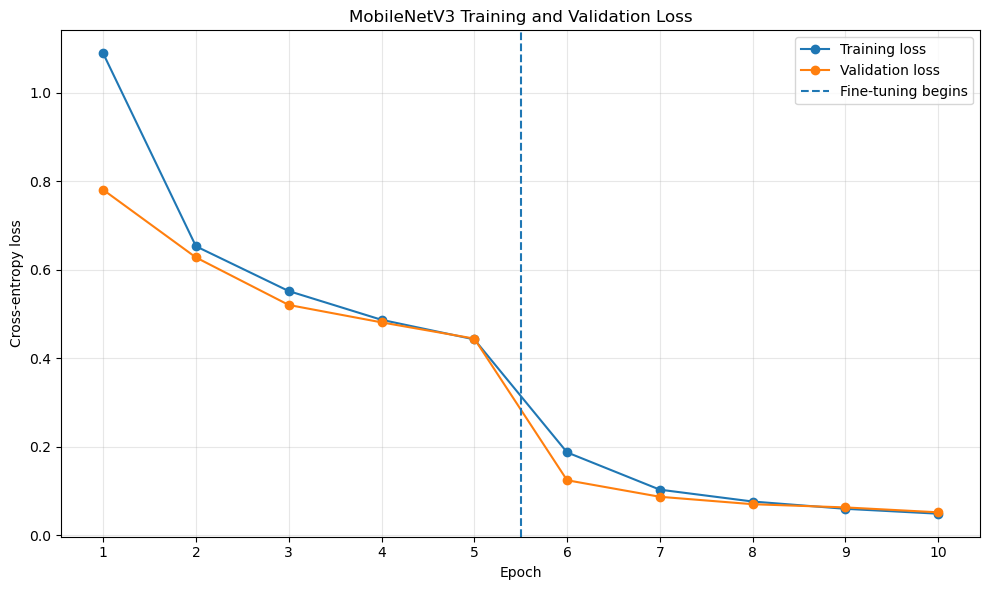

Loss figure saved to: /Users/liuyuhan/Desktop/traffic_recognition/results/figures/mobilenetv3_loss_curves.png


In [36]:
# Plot loss curves
fine_tuning_start_epoch = (len(feature_extraction_history) + 0.5)

plt.figure(figsize=(10, 6))

plt.plot(
    combined_history["global_epoch"],
    combined_history["train_loss"],
    marker="o",
    label="Training loss"
)

plt.plot(
    combined_history["global_epoch"],
    combined_history["validation_loss"],
    marker="o",
    label="Validation loss"
)

plt.axvline(
    x=fine_tuning_start_epoch,
    linestyle="--",
    label="Fine-tuning begins"
)

plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.title("MobileNetV3 Training and Validation Loss")
plt.xticks(combined_history["global_epoch"])
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

loss_figure_path = (figures_dir / "mobilenetv3_loss_curves.png")

plt.savefig(loss_figure_path, dpi=300, bbox_inches="tight")

plt.show()

print("Loss figure saved to:", loss_figure_path)

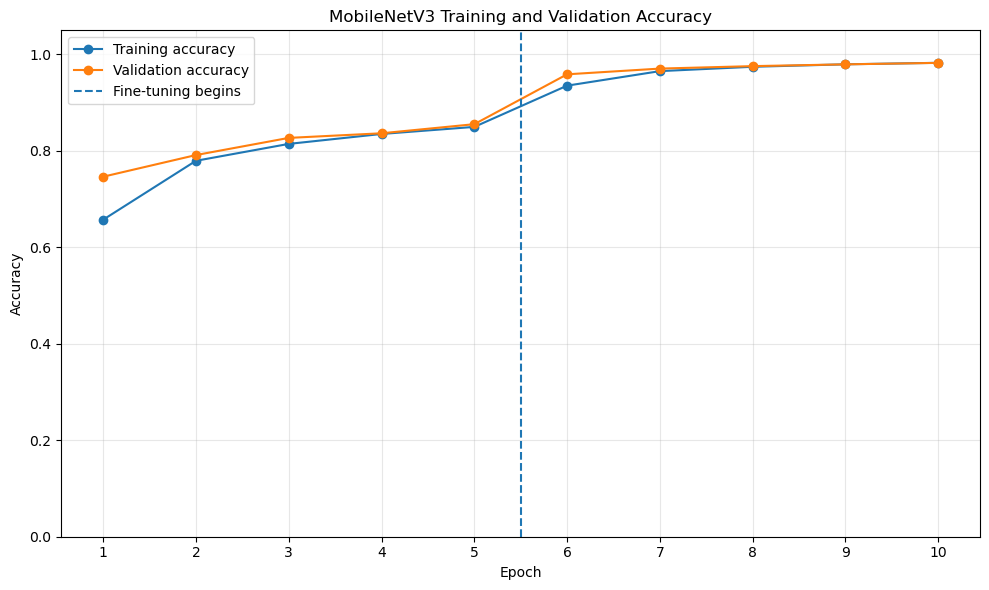

Accuracy figure saved to: /Users/liuyuhan/Desktop/traffic_recognition/results/figures/mobilenetv3_accuracy_curves.png


In [37]:
# Plot accuracy curves
plt.figure(figsize=(10, 6))

plt.plot(
    combined_history["global_epoch"],
    combined_history["train_accuracy"],
    marker="o",
    label="Training accuracy"
)

plt.plot(
    combined_history["global_epoch"],
    combined_history["validation_accuracy"],
    marker="o",
    label="Validation accuracy"
)

plt.axvline(
    x=fine_tuning_start_epoch,
    linestyle="--",
    label="Fine-tuning begins"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MobileNetV3 Training and Validation Accuracy")
plt.xticks(combined_history["global_epoch"])
plt.ylim(0, 1.05)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

accuracy_figure_path = (figures_dir / "mobilenetv3_accuracy_curves.png")

plt.savefig(accuracy_figure_path, dpi=300, bbox_inches="tight")

plt.show()

print("Accuracy figure saved to:", accuracy_figure_path)

In [38]:
# Training time summary
stage_time_summary = (
    combined_history
    .groupby("stage", as_index=False)
    .agg(
        epochs_completed=("epoch", "count"),
        total_time_seconds=(
            "epoch_time_seconds",
            "sum"
        ),
        mean_epoch_time_seconds=(
            "epoch_time_seconds",
            "mean"
        )
    )
)

stage_time_summary["total_time_minutes"] = (stage_time_summary["total_time_seconds"] / 60)

display(stage_time_summary)

,stage,epochs_completed,total_time_seconds,mean_epoch_time_seconds,total_time_minutes
0,Feature extraction,5,43996.163785,8799.232757,733.269396
1,Fine-tuning,5,12265.465868,2453.093174,204.424431


In [39]:
training_time_path = (results_dir / "mobilenetv3_training_time.csv")

stage_time_summary.to_csv(training_time_path, index=False)

print("Training-time summary saved to:", training_time_path)

Training-time summary saved to: /Users/liuyuhan/Desktop/traffic_recognition/results/mobilenetv3_training_time.csv


##### 16. Model Saving

The best model parameters selected according to validation loss are saved together with the class mapping and preprocessing information.

Saving this information ensures that the model can later be loaded consistently for comparison or inference.

In [40]:
model_path = ( models_dir / "mobilenetv3_transfer_learning_best.pth")

torch.save(
    {
        "model_name": "mobilenet_v3_large",
        "model_state_dict": model.state_dict(),
        "num_classes": num_classes,
        "label_to_index": label_to_index,
        "index_to_label": index_to_label,
        "class_display_names": class_display_names,
        "image_size": IMAGE_SIZE,
        "normalisation_mean": imagenet_mean,
        "normalisation_std": imagenet_std,
        "seed": SEED
    },
    model_path
)

print("Model saved to:", model_path)

Model saved to: /Users/liuyuhan/Desktop/traffic_recognition/models/mobilenetv3_transfer_learning_best.pth


##### 17. Final Evaluation on the Test Set

The test set is used only after training and model selection have been completed.

Predicted classes, confidence scores and ground-truth labels are collected for the calculation of overall and per-class evaluation metrics.

In [41]:
def generate_predictions(neural_network, data_loader, computation_device):
    neural_network.eval()

    all_true_labels = []
    all_predicted_labels = []
    all_confidences = []
    all_image_paths = []
    all_probabilities = []

    inference_start_time = time.time()

    with torch.no_grad():
        for images, labels, image_paths in data_loader:
            images = images.to(computation_device)

            outputs = neural_network(images)
            probabilities = torch.softmax(outputs, dim=1)

            confidence_values, predictions = (
                probabilities.max(dim=1)
            )

            all_true_labels.extend(
                labels.cpu().numpy().tolist()
            )

            all_predicted_labels.extend(
                predictions.cpu().numpy().tolist()
            )

            all_confidences.extend(
                confidence_values.cpu().numpy().tolist()
            )

            all_image_paths.extend(list(image_paths))

            all_probabilities.append(
                probabilities.cpu().numpy()
            )

    total_inference_time = (time.time() - inference_start_time)

    all_probabilities = np.concatenate(all_probabilities, axis=0)

    return {
        "true_labels": np.array(all_true_labels),
        "predicted_labels": np.array(
            all_predicted_labels
        ),
        "confidences": np.array(all_confidences),
        "image_paths": all_image_paths,
        "probabilities": all_probabilities,
        "inference_time_seconds": total_inference_time
    }

In [42]:
test_predictions = generate_predictions(
    neural_network=model,
    data_loader=test_loader,
    computation_device=device
)

y_true = test_predictions["true_labels"]
y_pred = test_predictions["predicted_labels"]
prediction_confidences = (test_predictions["confidences"])

test_image_paths = test_predictions["image_paths"]
test_probabilities = test_predictions["probabilities"]

test_inference_time = (test_predictions["inference_time_seconds"])

print("Number of test predictions:", len(y_pred))
print("Total inference time:", f"{test_inference_time:.2f} seconds")
print("Mean inference time per image:", f"{1000 * test_inference_time / len(y_pred):.3f} ms")

Number of test predictions: 12630
Total inference time: 331.23 seconds
Mean inference time per image: 26.226 ms


##### 18. Overall Classification Metrics

Accuracy reports the proportion of correctly classified test images.

Macro-averaged metrics give equal importance to every class, whereas weighted metrics account for the number of examples in each class. Reporting both is useful when the dataset contains class imbalance.

In [43]:
test_accuracy = accuracy_score(y_true, y_pred)

macro_precision, macro_recall, macro_f1, _ = (
    precision_recall_fscore_support(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )
)

weighted_precision, weighted_recall, weighted_f1, _ = (
    precision_recall_fscore_support(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )
)

overall_metrics = pd.DataFrame({
    "model": ["MobileNetV3-Large"],
    "accuracy": [test_accuracy],
    "macro_precision": [macro_precision],
    "macro_recall": [macro_recall],
    "macro_f1": [macro_f1],
    "weighted_precision": [weighted_precision],
    "weighted_recall": [weighted_recall],
    "weighted_f1": [weighted_f1],
    "test_images": [len(y_true)],
    "inference_time_seconds": [test_inference_time],
    "mean_inference_ms_per_image": [
        1000 * test_inference_time / len(y_true)
    ],
    "total_parameters": [total_parameters],
    "trainable_parameters_final_stage": [
        trainable_parameters
    ]
})

display(overall_metrics)

,model,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1,test_images,inference_time_seconds,mean_inference_ms_per_image,total_parameters,trainable_parameters_final_stage
0,MobileNetV3-Large,0.890657,0.848731,0.82717,0.832552,0.896361,0.890657,0.890309,12630,331.23445,26.226006,4257115,3035403


In [44]:
overall_metrics_path = (results_dir / "mobilenetv3_overall_metrics.csv")

overall_metrics.to_csv(overall_metrics_path, index=False)

print( "Overall metrics saved to:", overall_metrics_path)

Overall metrics saved to: /Users/liuyuhan/Desktop/traffic_recognition/results/mobilenetv3_overall_metrics.csv


In [45]:
# Summary
print("MobileNetV3 Test Performance")
print("-" * 40)
print(f"Accuracy:           {test_accuracy:.4f}")
print(f"Macro precision:    {macro_precision:.4f}")
print(f"Macro recall:       {macro_recall:.4f}")
print(f"Macro F1-score:     {macro_f1:.4f}")
print(f"Weighted precision: {weighted_precision:.4f}")
print(f"Weighted recall:    {weighted_recall:.4f}")
print(f"Weighted F1-score:  {weighted_f1:.4f}")

MobileNetV3 Test Performance
----------------------------------------
Accuracy:           0.8907
Macro precision:    0.8487
Macro recall:       0.8272
Macro F1-score:     0.8326
Weighted precision: 0.8964
Weighted recall:    0.8907
Weighted F1-score:  0.8903


##### 19. Classification Report

The classification report provides precision, recall, F1-score and support for every traffic sign class.

This provides more detailed information than overall accuracy and helps identify classes that remain difficult for the model.

In [46]:
class_indices = list(range(num_classes))

target_names = [class_display_names[index] for index in class_indices]

classification_report_dictionary = classification_report(
    y_true,
    y_pred,
    labels=class_indices,
    target_names=target_names,
    output_dict=True,
    zero_division=0
)

classification_report_df = (pd.DataFrame(classification_report_dictionary).transpose())

display(classification_report_df)

,precision,recall,f1-score,support
Class 0,0.701493,0.783333,0.740157,60.000000
Class 1,0.832895,0.879167,0.855405,720.000000
Class 2,0.776000,0.905333,0.835692,750.000000
Class 3,0.882353,0.766667,0.820452,450.000000
Class 4,0.925758,0.925758,0.925758,660.000000
Class 5,0.894934,0.757143,0.820292,630.000000
Class 6,0.991597,0.786667,0.877323,150.000000
Class 7,0.895706,0.973333,0.932907,450.000000
Class 8,0.939759,0.866667,0.901734,450.000000
Class 9,0.961303,0.983333,0.972194,480.000000


In [47]:
classification_report_path = (results_dir / "mobilenetv3_classification_report.csv")

classification_report_df.to_csv(classification_report_path)

print("Classification report saved to:", classification_report_path)

Classification report saved to: /Users/liuyuhan/Desktop/traffic_recognition/results/mobilenetv3_classification_report.csv


##### 20. Raw Confusion Matrix

The raw confusion matrix shows the number of test examples assigned to each predicted class.

Diagonal entries represent correct predictions, while off-diagonal entries represent classification errors.

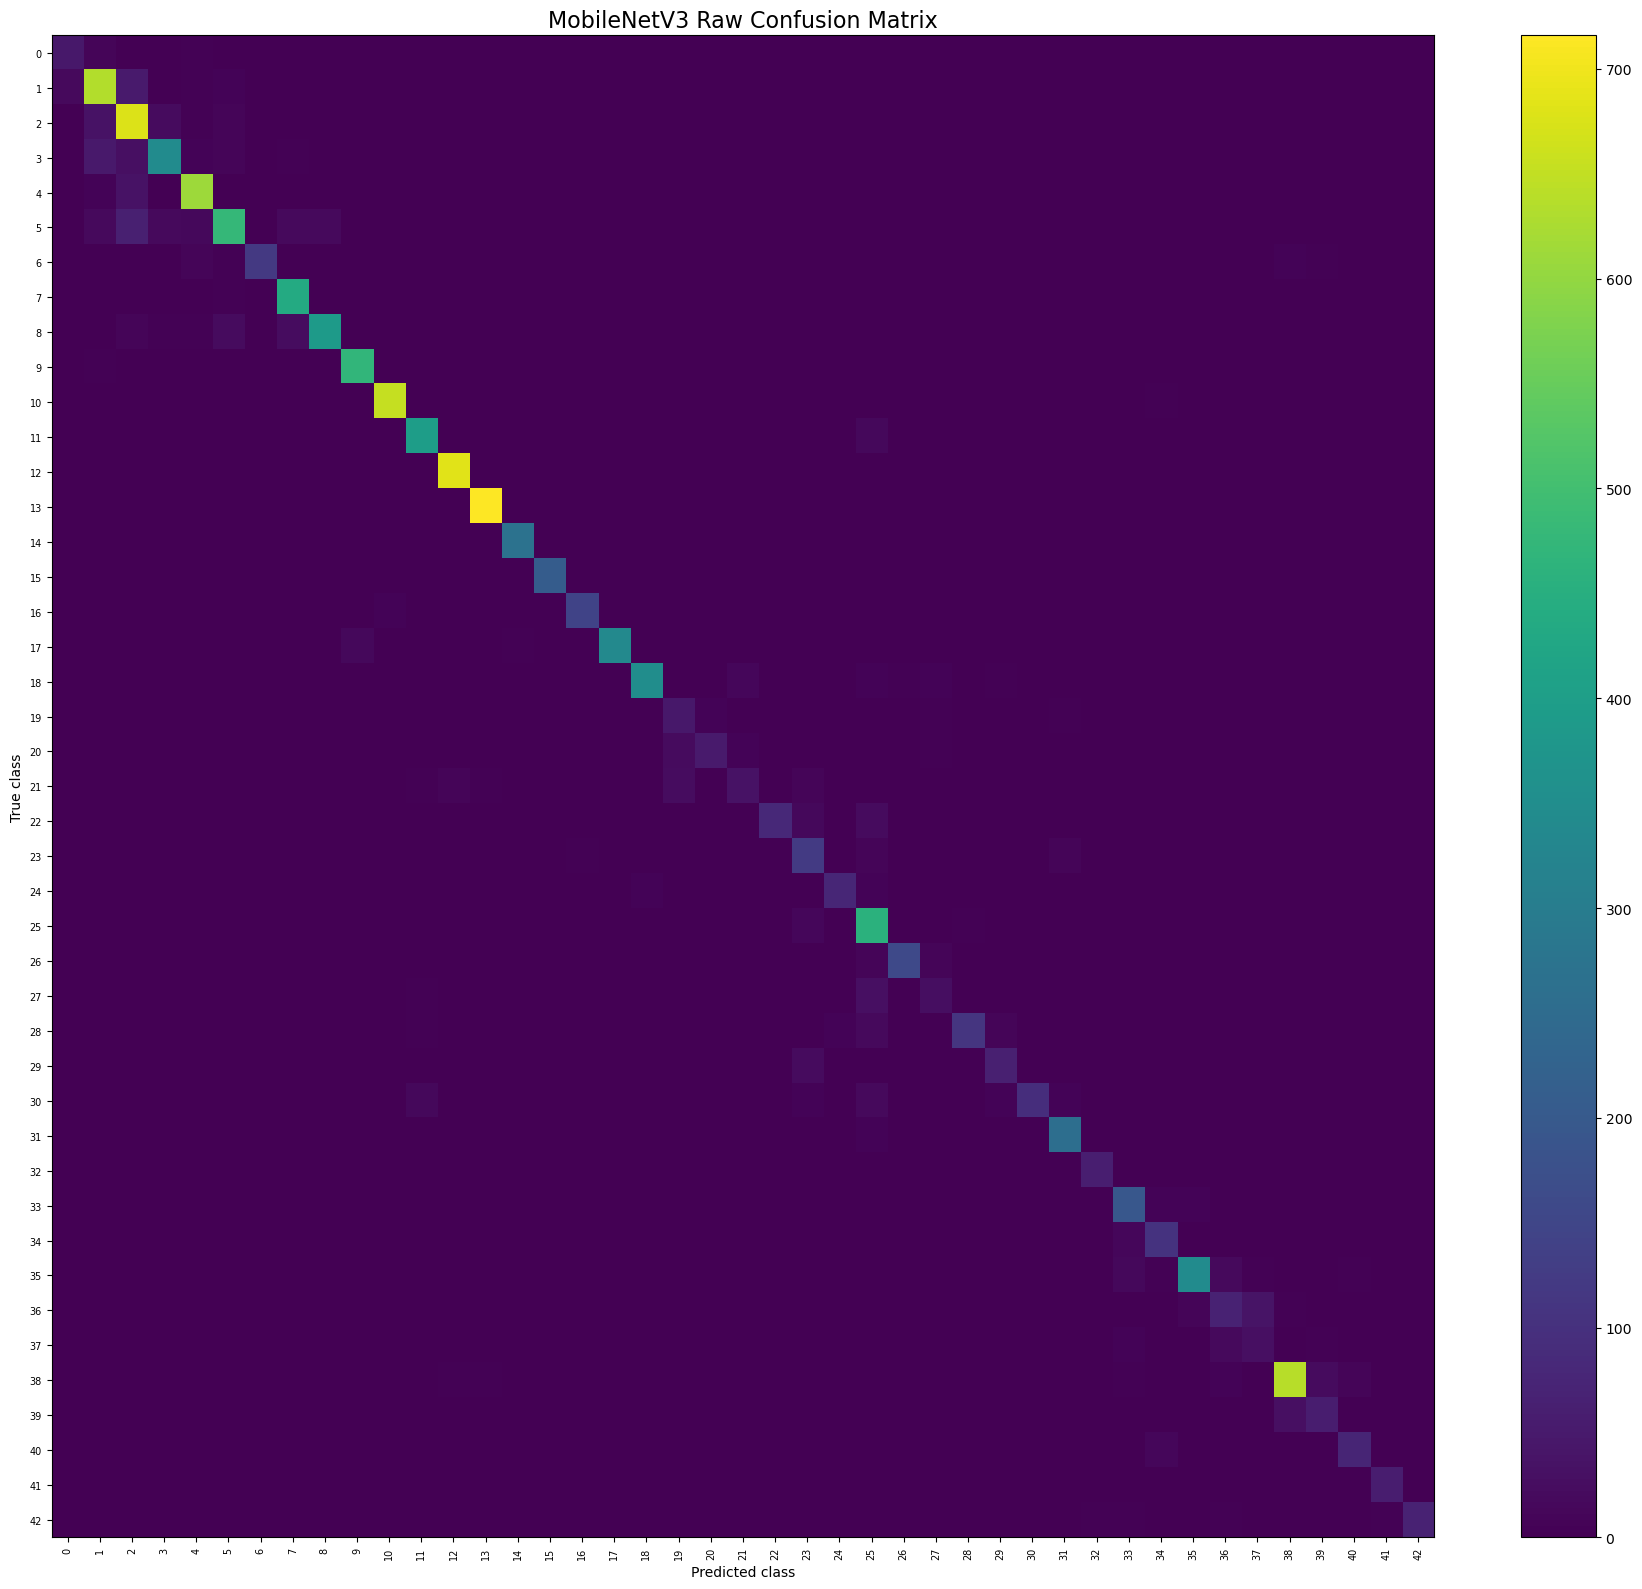

Raw confusion matrix saved to: /Users/liuyuhan/Desktop/traffic_recognition/results/figures/mobilenetv3_confusion_matrix_raw.png


In [48]:
raw_confusion_matrix = confusion_matrix(y_true, y_pred, labels=class_indices)

plt.figure(figsize=(18, 16))

plt.imshow(raw_confusion_matrix, interpolation="nearest", aspect="auto")

plt.title( "MobileNetV3 Raw Confusion Matrix", fontsize=16)

plt.xlabel("Predicted class")
plt.ylabel("True class")

plt.colorbar()

plt.xticks(
    ticks=class_indices,
    labels=[str(index_to_label[index]) for index in class_indices],
    rotation=90,
    fontsize=7
)

plt.yticks(
    ticks=class_indices,
    labels=[str(index_to_label[index]) for index in class_indices],
    fontsize=7
)

plt.tight_layout()

raw_confusion_matrix_path = ( figures_dir / "mobilenetv3_confusion_matrix_raw.png")

plt.savefig( raw_confusion_matrix_path, dpi=300, bbox_inches="tight")

plt.show()

print( "Raw confusion matrix saved to:", raw_confusion_matrix_path)

##### 21. Normalised Confusion Matrix

The confusion matrix is normalised by the number of true examples in each class.

Each row therefore represents the distribution of predictions for one true class. The diagonal values correspond to class-specific recall.

The normalised matrix is particularly useful when classes contain different numbers of test examples.

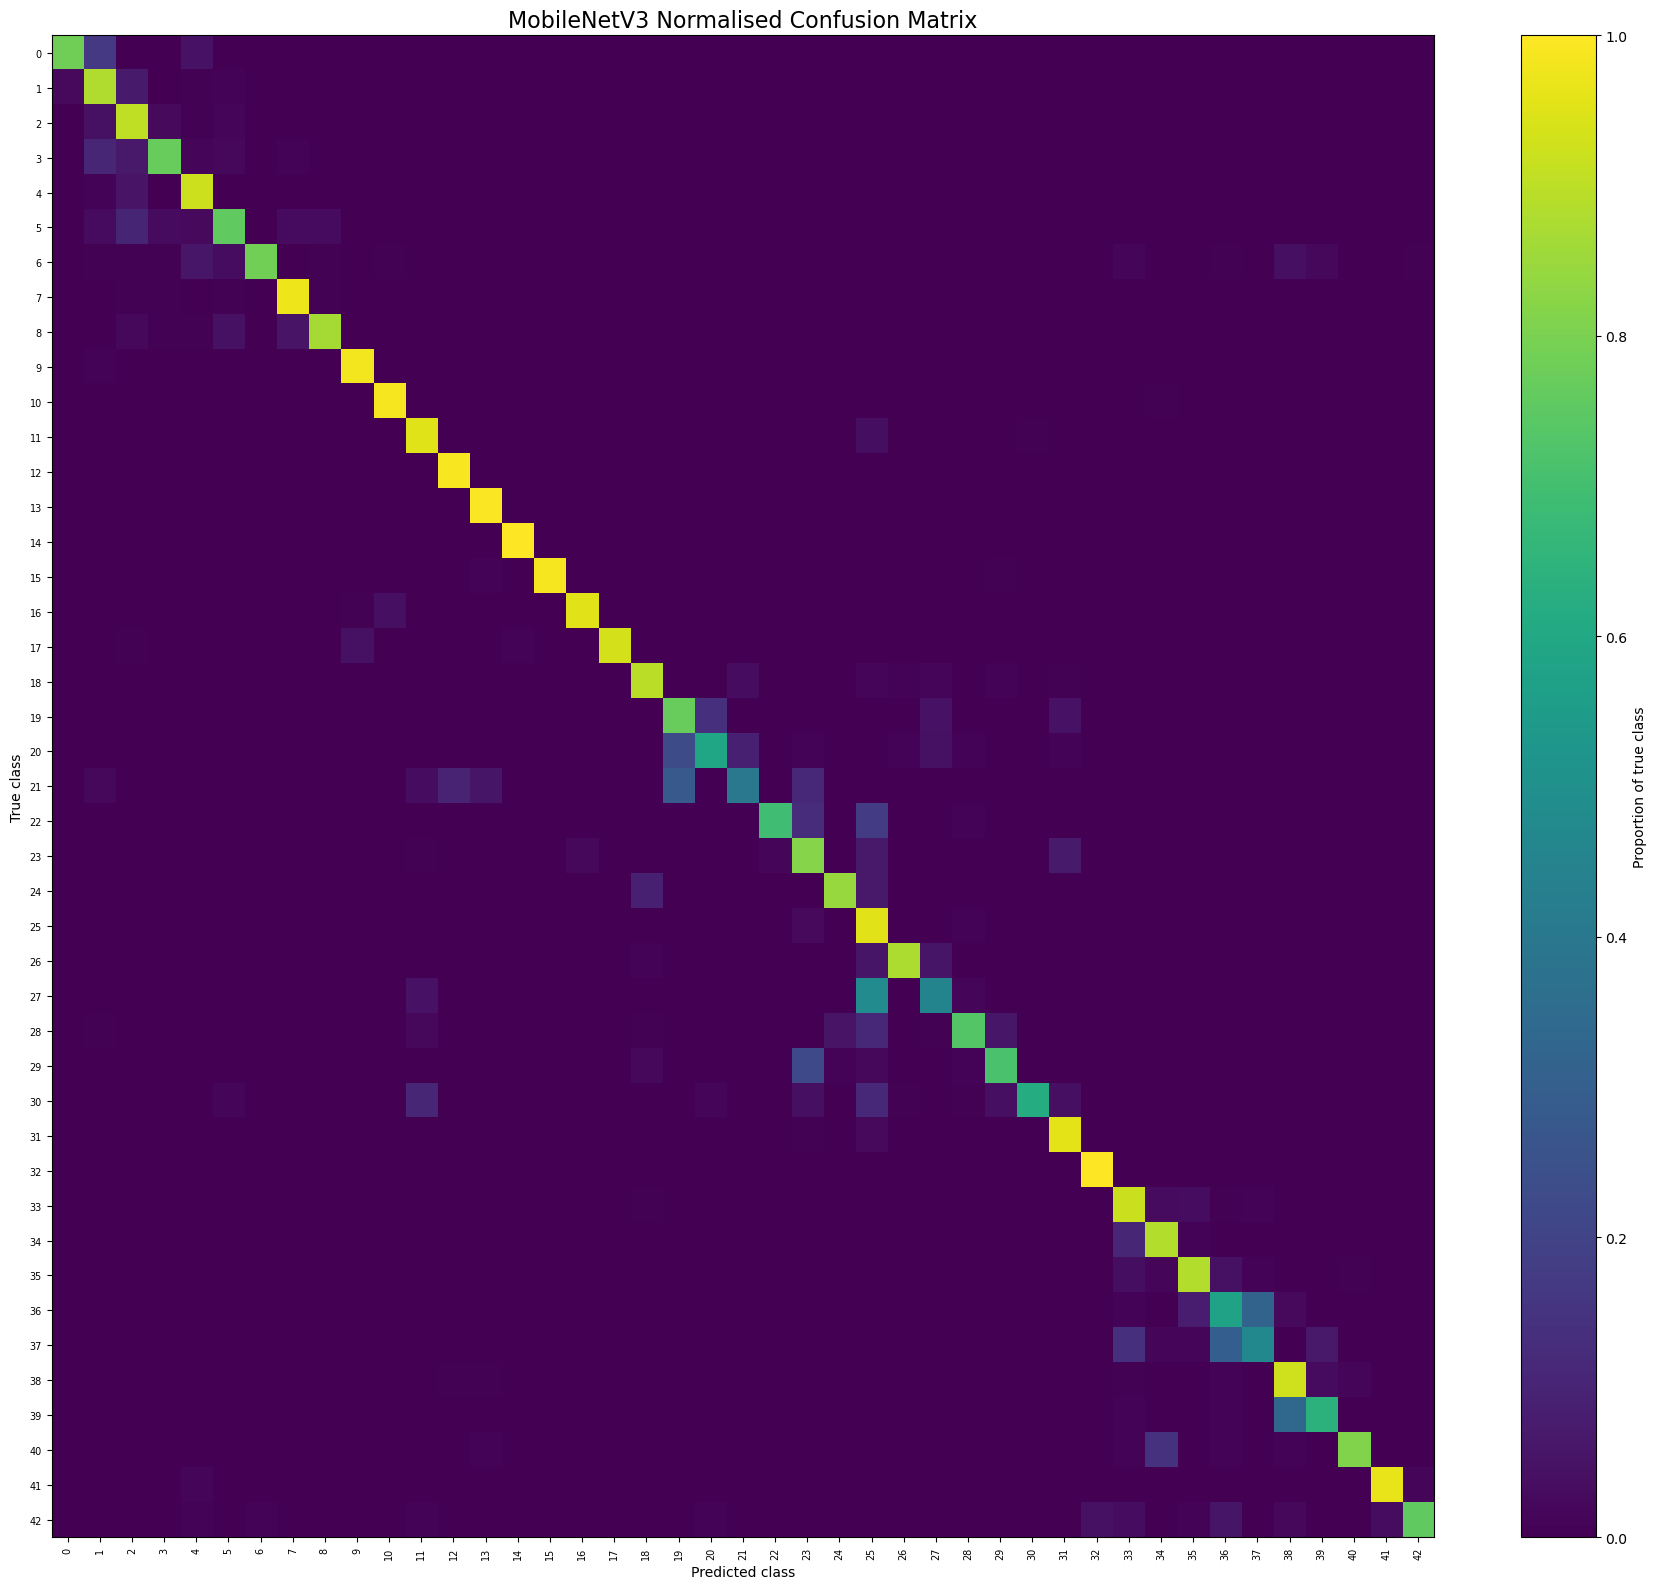

Normalised confusion matrix saved to: /Users/liuyuhan/Desktop/traffic_recognition/results/figures/mobilenetv3_confusion_matrix_normalised.png


In [49]:
normalised_confusion_matrix = confusion_matrix(
    y_true,
    y_pred,
    labels=class_indices,
    normalize="true"
)

plt.figure(figsize=(18, 16))

plt.imshow(
    normalised_confusion_matrix,
    interpolation="nearest",
    aspect="auto",
    vmin=0,
    vmax=1
)

plt.title("MobileNetV3 Normalised Confusion Matrix", fontsize=16)

plt.xlabel("Predicted class")
plt.ylabel("True class")

colour_bar = plt.colorbar()
colour_bar.set_label("Proportion of true class")

plt.xticks(
    ticks=class_indices,
    labels=[str(index_to_label[index]) for index in class_indices],
    rotation=90,
    fontsize=7
)

plt.yticks(
    ticks=class_indices,
    labels=[str(index_to_label[index]) for index in class_indices],
    fontsize=7
)

plt.tight_layout()

normalised_confusion_matrix_path = (figures_dir / "mobilenetv3_confusion_matrix_normalised.png")

plt.savefig(normalised_confusion_matrix_path, dpi=300, bbox_inches="tight")

plt.show()

print("Normalised confusion matrix saved to:", normalised_confusion_matrix_path)

In [50]:
# Save confusion matrices as CSV
raw_confusion_matrix_df = pd.DataFrame(
    raw_confusion_matrix,
    index=target_names,
    columns=target_names
)

normalised_confusion_matrix_df = pd.DataFrame(
    normalised_confusion_matrix,
    index=target_names,
    columns=target_names
)

raw_confusion_csv_path = (results_dir / "mobilenetv3_confusion_matrix_raw.csv")

normalised_confusion_csv_path = (results_dir / "mobilenetv3_confusion_matrix_normalised.csv")

raw_confusion_matrix_df.to_csv(raw_confusion_csv_path)

normalised_confusion_matrix_df.to_csv(normalised_confusion_csv_path)

print("Raw confusion matrix CSV saved to:", raw_confusion_csv_path)

print("Normalised confusion matrix CSV saved to:", normalised_confusion_csv_path)

Raw confusion matrix CSV saved to: /Users/liuyuhan/Desktop/traffic_recognition/results/mobilenetv3_confusion_matrix_raw.csv
Normalised confusion matrix CSV saved to: /Users/liuyuhan/Desktop/traffic_recognition/results/mobilenetv3_confusion_matrix_normalised.csv


##### 22. Per-Class Performance

Precision, recall, F1-score and support are calculated separately for every traffic sign class.

The per-class table is sorted by F1-score because F1-score balances precision and recall and provides a useful summary of class-level performance.

In [51]:
(
    class_precision,
    class_recall,
    class_f1,
    class_support
) = precision_recall_fscore_support(
    y_true,
    y_pred,
    labels=class_indices,
    zero_division=0
)

per_class_performance = pd.DataFrame({
    "encoded_class": class_indices,
    "original_class": [
        index_to_label[index]
        for index in class_indices
    ],
    "class_name": [
        class_display_names[index]
        for index in class_indices
    ],
    "precision": class_precision,
    "recall": class_recall,
    "f1_score": class_f1,
    "support": class_support
})

per_class_performance = (
    per_class_performance
    .sort_values(
        by="f1_score",
        ascending=False
    )
    .reset_index(drop=True)
)

display(per_class_performance)

,encoded_class,original_class,class_name,precision,recall,f1_score,support
0,14,14,Class 14,0.985348,0.996296,0.990792,270
1,15,15,Class 15,0.995192,0.985714,0.990431,210
2,13,13,Class 13,0.982167,0.994444,0.988268,720
3,10,10,Class 10,0.984894,0.987879,0.986384,660
4,12,12,Class 12,0.979914,0.989855,0.984859,690
5,9,9,Class 9,0.961303,0.983333,0.972194,480
6,32,32,Class 32,0.937500,1.000000,0.967742,60
7,17,17,Class 17,0.997041,0.936111,0.965616,360
8,16,16,Class 16,0.966216,0.953333,0.959732,150
9,11,11,Class 11,0.932243,0.950000,0.941038,420


In [52]:
per_class_performance_path = (results_dir / "mobilenetv3_per_class_performance.csv")

per_class_performance.to_csv(per_class_performance_path, index=False)

print("Per-class performance saved to:", per_class_performance_path)

Per-class performance saved to: /Users/liuyuhan/Desktop/traffic_recognition/results/mobilenetv3_per_class_performance.csv


##### 23. Best and Worst Performing Classes

The five classes with the highest and lowest F1-scores are identified.

This analysis highlights classes that are recognised reliably and classes that may require additional investigation, more training examples or improved image augmentation.

In [53]:
NUMBER_OF_CLASSES_TO_DISPLAY = min(5, num_classes)

best_classes = per_class_performance.head(NUMBER_OF_CLASSES_TO_DISPLAY).copy()

worst_classes = per_class_performance.tail(NUMBER_OF_CLASSES_TO_DISPLAY).sort_values(by="f1_score", ascending=True).copy()

print("Best performing classes:")
display(best_classes)

print("Worst performing classes:")
display(worst_classes)

Best performing classes:


,encoded_class,original_class,class_name,precision,recall,f1_score,support
0,14,14,Class 14,0.985348,0.996296,0.990792,270
1,15,15,Class 15,0.995192,0.985714,0.990431,210
2,13,13,Class 13,0.982167,0.994444,0.988268,720
3,10,10,Class 10,0.984894,0.987879,0.986384,660
4,12,12,Class 12,0.979914,0.989855,0.984859,690


Worst performing classes:


,encoded_class,original_class,class_name,precision,recall,f1_score,support
42,37,37,Class 37,0.388889,0.466667,0.424242,60
41,27,27,Class 27,0.509434,0.450000,0.477876,60
40,21,21,Class 21,0.631579,0.400000,0.489796,90
39,36,36,Class 36,0.570248,0.575000,0.572614,120
38,19,19,Class 19,0.500000,0.766667,0.605263,60


In [54]:
best_classes_path = (results_dir / "mobilenetv3_best_classes.csv")

worst_classes_path = (results_dir / "mobilenetv3_worst_classes.csv")

best_classes.to_csv(best_classes_path, index=False)

worst_classes.to_csv(worst_classes_path, index=False)

print("Best classes saved to:", best_classes_path)
print("Worst classes saved to:", worst_classes_path)

Best classes saved to: /Users/liuyuhan/Desktop/traffic_recognition/results/mobilenetv3_best_classes.csv
Worst classes saved to: /Users/liuyuhan/Desktop/traffic_recognition/results/mobilenetv3_worst_classes.csv


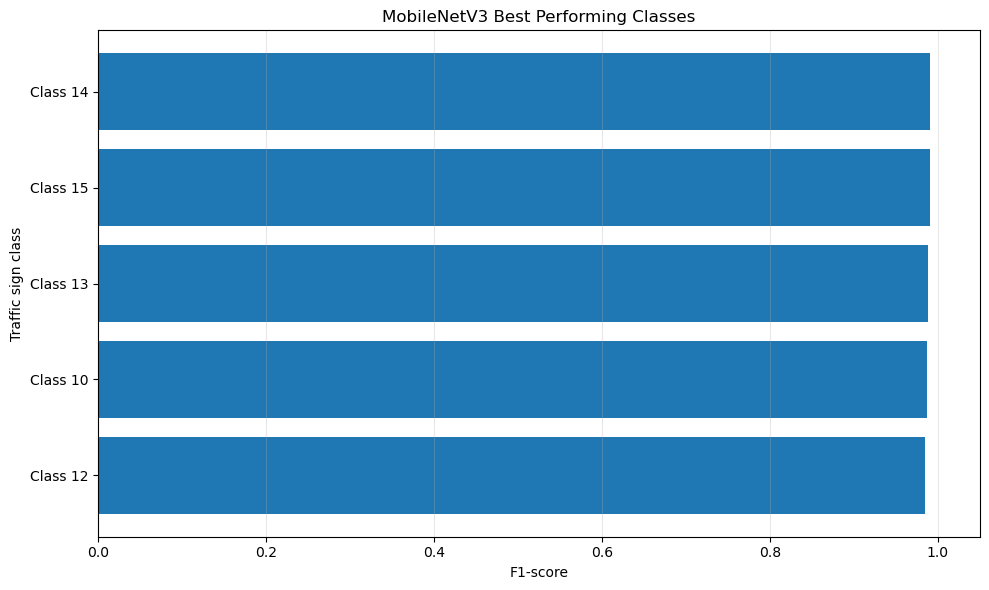

Best-class figure saved to: /Users/liuyuhan/Desktop/traffic_recognition/results/figures/mobilenetv3_best_classes.png


In [55]:
# Plot best classes
best_classes_for_plot = best_classes.sort_values(by="f1_score", ascending=True)
plt.figure(figsize=(10, 6))

plt.barh(best_classes_for_plot["class_name"], best_classes_for_plot["f1_score"])

plt.xlabel("F1-score")
plt.ylabel("Traffic sign class")
plt.title("MobileNetV3 Best Performing Classes")
plt.xlim(0, 1.05)
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()

best_classes_figure_path = (figures_dir / "mobilenetv3_best_classes.png")

plt.savefig(best_classes_figure_path, dpi=300, bbox_inches="tight")

plt.show()

print("Best-class figure saved to:", best_classes_figure_path)

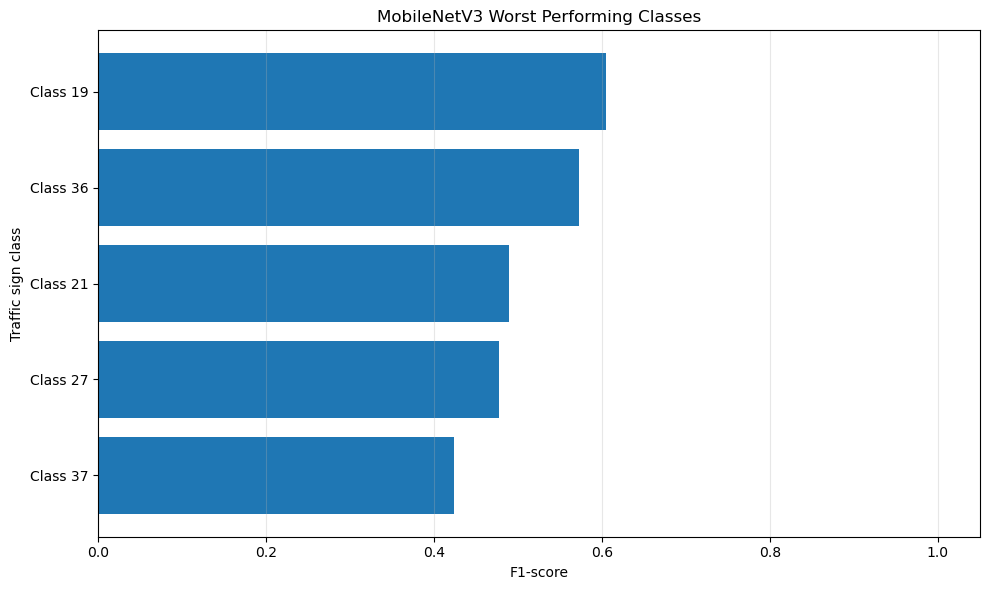

Worst-class figure saved to: /Users/liuyuhan/Desktop/traffic_recognition/results/figures/mobilenetv3_worst_classes.png


In [56]:
# Plot worst classes
plt.figure(figsize=(10, 6))
plt.barh(worst_classes["class_name"], worst_classes["f1_score"])

plt.xlabel("F1-score")
plt.ylabel("Traffic sign class")
plt.title("MobileNetV3 Worst Performing Classes")
plt.xlim(0, 1.05)
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()

worst_classes_figure_path = (figures_dir / "mobilenetv3_worst_classes.png")

plt.savefig(worst_classes_figure_path, dpi=300, bbox_inches="tight")

plt.show()

print("Worst-class figure saved to:", worst_classes_figure_path)

##### 24. Individual Prediction Results

A prediction table is created for every test image. It records:

- image path;
- true class;
- predicted class;
- prediction confidence;
- whether the prediction was correct.

This table supports later error analysis and model comparison.

In [57]:
prediction_results = pd.DataFrame({
    "image_path": test_image_paths,
    "true_encoded_class": y_true,
    "predicted_encoded_class": y_pred,
    "true_original_class": [
        index_to_label[index]
        for index in y_true
    ],
    "predicted_original_class": [
        index_to_label[index]
        for index in y_pred
    ],
    "true_class_name": [
        class_display_names[index]
        for index in y_true
    ],
    "predicted_class_name": [
        class_display_names[index]
        for index in y_pred
    ],
    "confidence": prediction_confidences,
    "correct": y_true == y_pred
})

display(prediction_results.head())

,image_path,true_encoded_class,predicted_encoded_class,true_original_class,predicted_original_class,true_class_name,predicted_class_name,confidence,correct
0,/Users/liuyuhan/Desktop/traffic_recognition/da...,16,16,16,16,Class 16,Class 16,1.000000,True
1,/Users/liuyuhan/Desktop/traffic_recognition/da...,1,1,1,1,Class 1,Class 1,0.999998,True
2,/Users/liuyuhan/Desktop/traffic_recognition/da...,38,38,38,38,Class 38,Class 38,0.999684,True
3,/Users/liuyuhan/Desktop/traffic_recognition/da...,33,33,33,33,Class 33,Class 33,0.963427,True
4,/Users/liuyuhan/Desktop/traffic_recognition/da...,11,11,11,11,Class 11,Class 11,1.000000,True


In [58]:
prediction_results_path = (results_dir / "mobilenetv3_test_predictions.csv")

prediction_results.to_csv(prediction_results_path, index=False)

print("Test predictions saved to:", prediction_results_path)

Test predictions saved to: /Users/liuyuhan/Desktop/traffic_recognition/results/mobilenetv3_test_predictions.csv


##### 25. Error Analysis

Incorrect predictions are examined to determine whether errors are concentrated in particular class pairs.

Possible causes of error include:

- visually similar traffic signs;
- low image resolution;
- illumination differences;
- partial occlusion;
- class imbalance;
- insufficient examples of particular classes.

In [59]:
incorrect_predictions = prediction_results[prediction_results["correct"] == False].copy()

number_incorrect = len(incorrect_predictions)
error_rate = number_incorrect / len(prediction_results)

print("Incorrect predictions:", number_incorrect)
print(f"Test error rate: {error_rate:.4f}")

display(incorrect_predictions.sort_values(by="confidence", ascending=False).head(10))

Incorrect predictions: 1381
Test error rate: 0.1093


,image_path,true_encoded_class,predicted_encoded_class,true_original_class,predicted_original_class,true_class_name,predicted_class_name,confidence,correct
10564,/Users/liuyuhan/Desktop/traffic_recognition/da...,39,38,39,38,Class 39,Class 38,0.999983,False
4667,/Users/liuyuhan/Desktop/traffic_recognition/da...,40,34,40,34,Class 40,Class 34,0.999953,False
6862,/Users/liuyuhan/Desktop/traffic_recognition/da...,39,38,39,38,Class 39,Class 38,0.999940,False
781,/Users/liuyuhan/Desktop/traffic_recognition/da...,39,38,39,38,Class 39,Class 38,0.999937,False
9183,/Users/liuyuhan/Desktop/traffic_recognition/da...,39,38,39,38,Class 39,Class 38,0.999929,False
5369,/Users/liuyuhan/Desktop/traffic_recognition/da...,40,34,40,34,Class 40,Class 34,0.999917,False
5538,/Users/liuyuhan/Desktop/traffic_recognition/da...,11,25,11,25,Class 11,Class 25,0.999887,False
1475,/Users/liuyuhan/Desktop/traffic_recognition/da...,18,25,18,25,Class 18,Class 25,0.999880,False
1746,/Users/liuyuhan/Desktop/traffic_recognition/da...,39,38,39,38,Class 39,Class 38,0.999836,False
10845,/Users/liuyuhan/Desktop/traffic_recognition/da...,39,38,39,38,Class 39,Class 38,0.999822,False


In [60]:
# Most common class confusions
if len(incorrect_predictions) > 0:
    common_confusions = (
        incorrect_predictions
        .groupby(
            [
                "true_original_class",
                "predicted_original_class",
                "true_class_name",
                "predicted_class_name"
            ]
        )
        .size()
        .reset_index(name="error_count")
        .sort_values(
            by="error_count",
            ascending=False
        )
        .reset_index(drop=True)
    )

    display(common_confusions.head(15))

    common_confusions_path = (results_dir / "mobilenetv3_common_confusions.csv"
    )

    common_confusions.to_csv(common_confusions_path, index=False)

    print("Common confusions saved to:", common_confusions_path)
else:
    common_confusions = pd.DataFrame()

    print("No incorrect test predictions were recorded.")

,true_original_class,predicted_original_class,true_class_name,predicted_class_name,error_count
0,5,2,Class 5,Class 2,64
1,1,2,Class 1,Class 2,51
2,3,1,Class 3,Class 1,49
3,36,37,Class 36,Class 37,38
4,4,2,Class 4,Class 2,34
5,2,1,Class 2,Class 1,34
6,39,38,Class 39,Class 38,30
7,3,2,Class 3,Class 2,30
8,27,25,Class 27,Class 25,29
9,21,19,Class 21,Class 19,25


Common confusions saved to: /Users/liuyuhan/Desktop/traffic_recognition/results/mobilenetv3_common_confusions.csv


In [61]:
# Visualise misclassified examples
def load_original_image(image_path):
    with Image.open(image_path) as image:
        return image.convert("RGB")

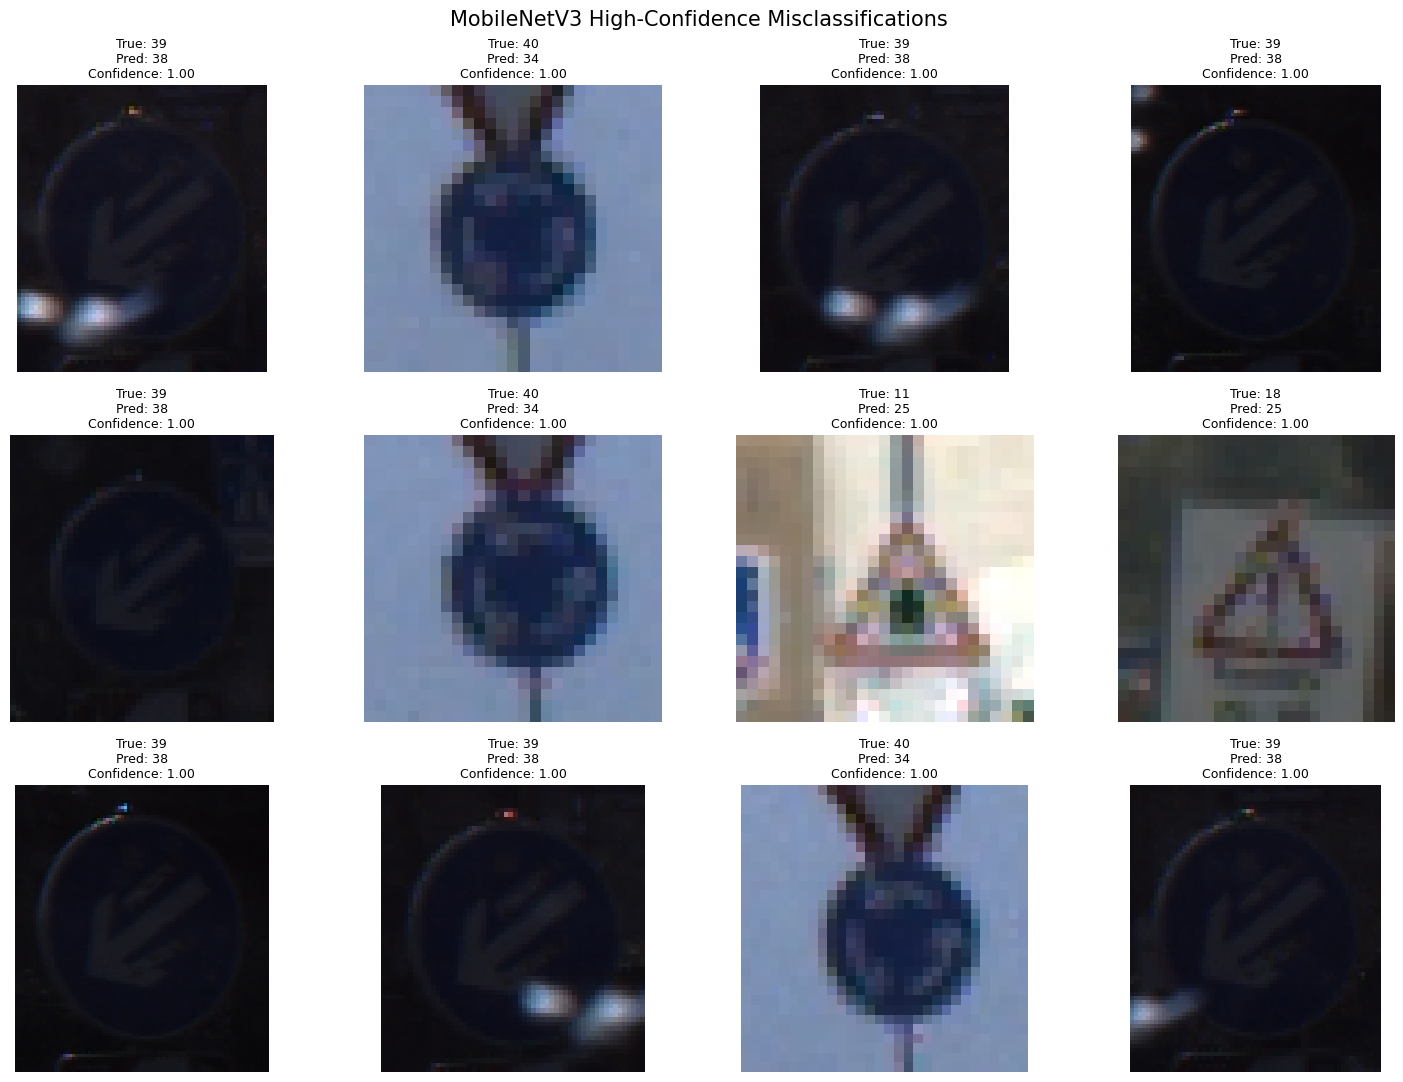

Misclassified examples saved to: /Users/liuyuhan/Desktop/traffic_recognition/results/figures/mobilenetv3_misclassified_examples.png


In [62]:
NUMBER_OF_ERRORS_TO_SHOW = min(12, len(incorrect_predictions))

if NUMBER_OF_ERRORS_TO_SHOW > 0:
    # Show high-confidence mistakes because these are particularly informative for error analysis.
    errors_to_show = (
        incorrect_predictions
        .sort_values(
            by="confidence",
            ascending=False
        )
        .head(NUMBER_OF_ERRORS_TO_SHOW)
        .reset_index(drop=True)
    )

    figure, axes = plt.subplots(3, 4, figsize=(15, 11))

    axes = axes.flatten()

    for axis in axes:
        axis.axis("off")

    for index in range(NUMBER_OF_ERRORS_TO_SHOW):
        row = errors_to_show.iloc[index]

        image = load_original_image(row["image_path"])

        axes[index].imshow(image)

        title = (
            f"True: {row['true_original_class']}\n"
            f"Pred: {row['predicted_original_class']}\n"
            f"Confidence: {row['confidence']:.2f}"
        )

        axes[index].set_title(title, fontsize=9)

    plt.suptitle("MobileNetV3 High-Confidence Misclassifications", fontsize=15)

    plt.tight_layout()

    error_examples_path = (figures_dir / "mobilenetv3_misclassified_examples.png")

    plt.savefig(error_examples_path, dpi=300, bbox_inches="tight")

    plt.show()

    print("Misclassified examples saved to:", error_examples_path)
else:
    print("There are no misclassified examples to display.")

##### 26. Class Frequency and Performance

The relationship between training class frequency and test F1-score is examined.

If classes with fewer training examples tend to have lower F1-scores, class imbalance may be one reason for weaker performance. However, visual similarity and image quality may also contribute to the observed errors.

In [63]:
training_class_counts = (
    train_df[label_column]
    .value_counts()
    .rename_axis("original_class")
    .reset_index(name="training_samples")
)

class_frequency_performance = (
    per_class_performance
    .merge(training_class_counts, on="original_class", how="left")
)

display(class_frequency_performance.sort_values(by="training_samples"))

,encoded_class,original_class,class_name,precision,recall,f1_score,support,training_samples
38,19,19,Class 19,0.500000,0.766667,0.605263,60,168
42,37,37,Class 37,0.388889,0.466667,0.424242,60,168
33,0,0,Class 0,0.701493,0.783333,0.740157,60,168
6,32,32,Class 32,0.937500,1.000000,0.967742,60,192
41,27,27,Class 27,0.509434,0.450000,0.477876,60,192
13,41,41,Class 41,0.892308,0.966667,0.928000,60,192
22,42,42,Class 42,0.971429,0.755556,0.850000,90,192
20,24,24,Class 24,0.883721,0.844444,0.863636,90,216
34,29,29,Class 29,0.761905,0.711111,0.735632,90,216
37,39,39,Class 39,0.666667,0.644444,0.655367,90,240


In [64]:
frequency_performance_correlation = (
    class_frequency_performance[
        ["training_samples", "f1_score"]
    ]
    .corr(method="spearman")
    .iloc[0, 1]
)

print(
    "Spearman correlation between training samples "
    "and class F1-score:",
    f"{frequency_performance_correlation:.4f}"
)

Spearman correlation between training samples and class F1-score: 0.5362


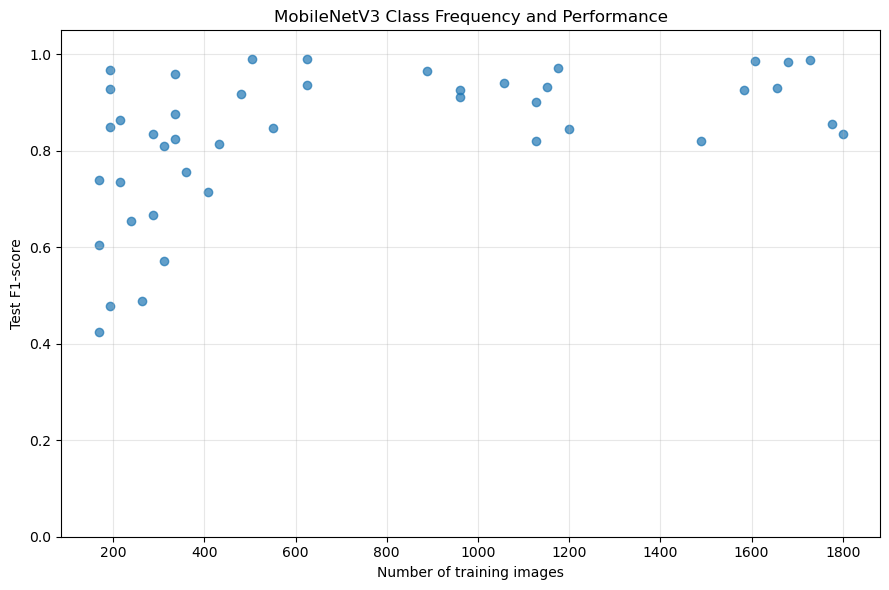

Frequency-performance figure saved to: /Users/liuyuhan/Desktop/traffic_recognition/results/figures/mobilenetv3_class_frequency_vs_f1.png


In [65]:
plt.figure(figsize=(9, 6))

plt.scatter(class_frequency_performance["training_samples"], class_frequency_performance["f1_score"], alpha=0.7)

plt.xlabel("Number of training images")
plt.ylabel("Test F1-score")
plt.title("MobileNetV3 Class Frequency and Performance")
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.tight_layout()

frequency_performance_figure_path = (figures_dir / "mobilenetv3_class_frequency_vs_f1.png")

plt.savefig(frequency_performance_figure_path, dpi=300, bbox_inches="tight")

plt.show()

print("Frequency-performance figure saved to:", frequency_performance_figure_path)

In [66]:
class_frequency_performance_path = (results_dir / "mobilenetv3_class_frequency_performance.csv")

class_frequency_performance.to_csv(class_frequency_performance_path, index=False)

print("Class-frequency analysis saved to:", class_frequency_performance_path)

Class-frequency analysis saved to: /Users/liuyuhan/Desktop/traffic_recognition/results/mobilenetv3_class_frequency_performance.csv


##### 27. Prediction Confidence

The confidence distributions of correct and incorrect predictions are compared.

A well-behaved classifier would generally assign higher confidence to correct predictions. High-confidence mistakes may indicate systematic confusion between visually similar classes.

In [67]:
correct_confidences = prediction_results.loc[prediction_results["correct"] == True, "confidence"]

incorrect_confidences = prediction_results.loc[prediction_results["correct"] == False, "confidence"]

print("Mean confidence for correct predictions:", f"{correct_confidences.mean():.4f}")

if len(incorrect_confidences) > 0:
    print("Mean confidence for incorrect predictions:", f"{incorrect_confidences.mean():.4f}")
else:
    print( "No incorrect predictions were available for confidence analysis.")

Mean confidence for correct predictions: 0.9690
Mean confidence for incorrect predictions: 0.7353


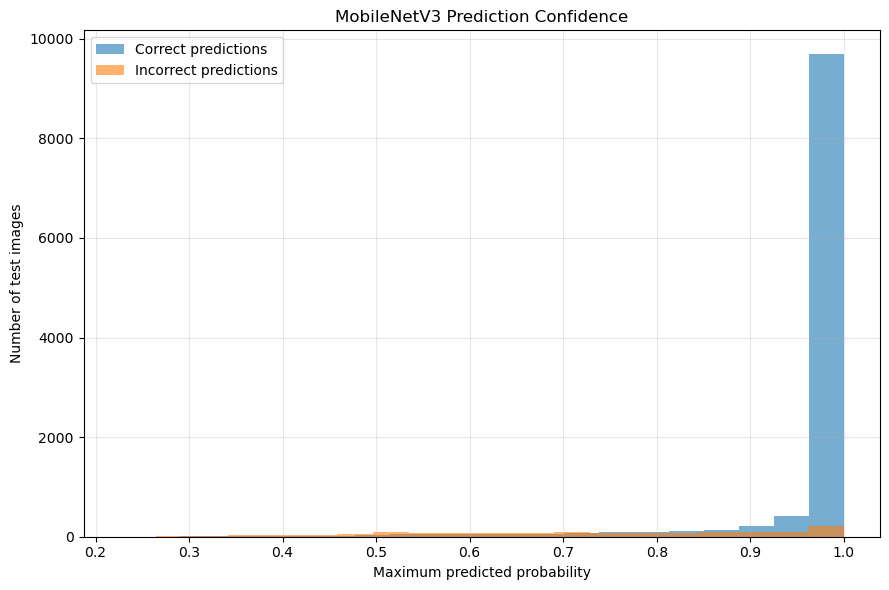

Confidence figure saved to: /Users/liuyuhan/Desktop/traffic_recognition/results/figures/mobilenetv3_prediction_confidence.png


In [68]:
plt.figure(figsize=(9, 6))

plt.hist(correct_confidences, bins=20, alpha=0.6, label="Correct predictions")

if len(incorrect_confidences) > 0:
    plt.hist(incorrect_confidences, bins=20, alpha=0.6, label="Incorrect predictions")

plt.xlabel("Maximum predicted probability")
plt.ylabel("Number of test images")
plt.title("MobileNetV3 Prediction Confidence")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

confidence_figure_path = (figures_dir / "mobilenetv3_prediction_confidence.png")

plt.savefig(confidence_figure_path, dpi=300, bbox_inches="tight")

plt.show()

print("Confidence figure saved to:", confidence_figure_path)

##### 28. Experiment Summary

The following table provides a compact summary of the MobileNetV3 experiment. It contains the key values required for comparison with the HOG + SVM, custom CNN and ResNet18 models.

In [69]:
best_validation_accuracy = combined_history["validation_accuracy"].max()

best_validation_loss = combined_history["validation_loss"].min()

total_training_time_seconds = combined_history["epoch_time_seconds"].sum()

experiment_summary = pd.DataFrame({
    "model": ["MobileNetV3-Large"],
    "pretrained": [True],
    "input_size": [IMAGE_SIZE],
    "batch_size": [BATCH_SIZE],
    "feature_extraction_epochs": [
        len(feature_extraction_history)
    ],
    "fine_tuning_epochs": [
        len(fine_tuning_history)
    ],
    "best_validation_accuracy": [
        best_validation_accuracy
    ],
    "best_validation_loss": [
        best_validation_loss
    ],
    "test_accuracy": [test_accuracy],
    "macro_precision": [macro_precision],
    "macro_recall": [macro_recall],
    "macro_f1": [macro_f1],
    "weighted_f1": [weighted_f1],
    "total_parameters": [total_parameters],
    "total_training_time_seconds": [
        total_training_time_seconds
    ],
    "total_training_time_minutes": [
        total_training_time_seconds / 60
    ],
    "mean_inference_ms_per_image": [
        1000 * test_inference_time / len(y_true)
    ],
    "device": [str(device)],
    "random_seed": [SEED]
})

display(experiment_summary)

,model,pretrained,input_size,batch_size,feature_extraction_epochs,fine_tuning_epochs,best_validation_accuracy,best_validation_loss,test_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,total_parameters,total_training_time_seconds,total_training_time_minutes,mean_inference_ms_per_image,device,random_seed
0,MobileNetV3-Large,True,224,32,5,5,0.98253,0.051845,0.890657,0.848731,0.82717,0.832552,0.890309,4257115,56261.629653,937.693828,26.226006,cpu,42


In [70]:
experiment_summary_path = (results_dir / "mobilenetv3_experiment_summary.csv")

experiment_summary.to_csv(experiment_summary_path, index=False)

print("Experiment summary saved to:", experiment_summary_path)

Experiment summary saved to: /Users/liuyuhan/Desktop/traffic_recognition/results/mobilenetv3_experiment_summary.csv


In [71]:
# List generated files
generated_files = [
    model_path,
    stage_one_history_path,
    stage_two_history_path,
    combined_history_path,
    training_time_path,
    overall_metrics_path,
    classification_report_path,
    raw_confusion_csv_path,
    normalised_confusion_csv_path,
    per_class_performance_path,
    best_classes_path,
    worst_classes_path,
    prediction_results_path,
    class_frequency_performance_path,
    experiment_summary_path,
    sample_figure_path,
    loss_figure_path,
    accuracy_figure_path,
    raw_confusion_matrix_path,
    normalised_confusion_matrix_path,
    best_classes_figure_path,
    worst_classes_figure_path,
    frequency_performance_figure_path,
    confidence_figure_path
]

if len(incorrect_predictions) > 0:
    generated_files.append(results_dir / "mobilenetv3_common_confusions.csv")

    generated_files.append(figures_dir / "mobilenetv3_misclassified_examples.png")

print("Generated experiment files:\n")

for generated_file in generated_files:
    status = "Found" if generated_file.exists() else "Missing"
    print(f"[{status}] {generated_file}")

Generated experiment files:

[Found] /Users/liuyuhan/Desktop/traffic_recognition/models/mobilenetv3_transfer_learning_best.pth
[Found] /Users/liuyuhan/Desktop/traffic_recognition/results/mobilenetv3_feature_extraction_history.csv
[Found] /Users/liuyuhan/Desktop/traffic_recognition/results/mobilenetv3_fine_tuning_history.csv
[Found] /Users/liuyuhan/Desktop/traffic_recognition/results/mobilenetv3_training_history.csv
[Found] /Users/liuyuhan/Desktop/traffic_recognition/results/mobilenetv3_training_time.csv
[Found] /Users/liuyuhan/Desktop/traffic_recognition/results/mobilenetv3_overall_metrics.csv
[Found] /Users/liuyuhan/Desktop/traffic_recognition/results/mobilenetv3_classification_report.csv
[Found] /Users/liuyuhan/Desktop/traffic_recognition/results/mobilenetv3_confusion_matrix_raw.csv
[Found] /Users/liuyuhan/Desktop/traffic_recognition/results/mobilenetv3_confusion_matrix_normalised.csv
[Found] /Users/liuyuhan/Desktop/traffic_recognition/results/mobilenetv3_per_class_performance.csv
[F

##### 29. Discussion

The MobileNetV3-Large transfer learning model achieved a test accuracy of **89.07%** and a macro F1-score of **83.26%**. Its weighted F1-score was higher at **89.03%**, indicating that the model performed more strongly on classes containing larger numbers of test examples.

The training curves showed consistent improvement during both stages. During feature extraction, validation accuracy increased from **74.65%** to **85.54%**, while validation loss decreased from **0.7804** to **0.4442**. After the final three feature blocks were unfrozen, fine-tuning produced a substantial improvement. Validation accuracy reached **98.25%**, and validation loss decreased further to **0.0518**. Training and validation performance remained close throughout fine-tuning, with no clear divergence between the two curves.

However, the final test accuracy was approximately **9.18 percentage points lower** than the best validation accuracy. This suggests that the validation set may have been more similar to the training set than the independent test set. Since the training and validation sets were created from the same original training data, visually similar images or images from the same capture sequence may have occurred across both subsets. The separate test set may also contain more difficult lighting conditions, viewpoints, image scales or background variation. Therefore, the validation result may provide an optimistic estimate of performance on fully unseen data.

The difference between the macro F1-score (**83.26%**) and weighted F1-score (**89.03%**) was noticeable. This indicates that performance was not fully consistent across all classes and that classes with larger support had a stronger influence on the weighted result. The five strongest-performing classes were Classes **14, 15, 13, 10 and 12**, with F1-scores between **98.49% and 99.08%**. In contrast, Classes **37, 27, 21, 36 and 19** produced the lowest F1-scores, ranging from **42.42% to 60.53%**.

The most frequent errors were concentrated among several similar class groups. For example, Class 5 was predicted as Class 2 on **64** occasions, Class 1 was predicted as Class 2 on **51** occasions, and Class 3 was predicted as Class 1 on **49** occasions. Other notable confusions included Class 36 with Class 37, Class 39 with Class 38, and Class 27 with Class 25. These repeated class-pair errors suggest that visually similar shape, colour or internal sign patterns contributed to the remaining mistakes.

The Spearman correlation between the number of training samples and class F1-score was **0.5362**, indicating a moderate positive relationship. Classes with more training examples generally tended to achieve better performance. However, the relationship was not perfect. Some relatively small classes, such as Class 32, still achieved a high F1-score, showing that class frequency alone does not explain performance. Visual distinctiveness, image quality and similarity between categories are also likely to influence classification difficulty.

Correct predictions had a mean confidence of **96.90%**, compared with **73.53%** for incorrect predictions. This shows that correct predictions were generally associated with higher confidence. Nevertheless, several mistakes were still made with high confidence, suggesting that the predicted probabilities should not automatically be interpreted as fully calibrated confidence estimates.

MobileNetV3 contained approximately **4.26 million parameters** and required an average of **26.23 ms per test image** for end-to-end prediction on the local CPU, including image loading and preprocessing. The recorded wall-clock training time was affected by substantial variation between epochs and likely included interruptions or system-level delays. It should therefore be interpreted cautiously and should not be used alone to compare computational efficiency with ResNet18.

MobileNetV3 has fewer parameters than many conventional convolutional architectures. However, the recorded wall-clock training time was affected by interruptions during local CPU execution and is therefore not treated as a reliable standalone measure of architectural efficiency.

Overall, fine-tuning MobileNetV3 produced strong validation performance and good overall test accuracy. However, the lower macro F1-score, weak performance on several minority classes and the gap between validation and test accuracy show that overall accuracy alone does not fully describe the model's generalisation performance.

##### 30. Conclusion

This notebook implemented MobileNetV3-Large as the second transfer learning model for traffic sign recognition.

The final model achieved a test accuracy of **89.07%**, a macro F1-score of **83.26%** and a weighted F1-score of **89.03%**. Partial fine-tuning substantially improved validation performance compared with training the classification head alone.

The results also showed that model performance varied across classes. Classes with more training examples generally achieved higher F1-scores, although class frequency did not fully explain the observed differences. Several systematic confusions occurred between visually similar traffic sign categories.

A noticeable gap remained between the best validation accuracy of **98.25%** and the test accuracy of **89.07%**. This indicates that the independent test set was more challenging and provides a more realistic estimate of generalisation performance.

The saved metrics, predictions, confusion matrices and efficiency measurements can now be used in `07_model_comparison.ipynb` to compare MobileNetV3 with HOG + SVM, the custom CNN and ResNet18. The final comparison should consider not only overall accuracy, but also macro F1-score, per-class performance, parameter count and inference efficiency.